In [ ]:
!pip install fairlearn
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.5/135.5 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.7/265.7 kB 11.6 MB/s eta 0:00:00


In [ ]:
"""Shared input validation for design-aware cross-validation.

Lower-level helpers that raise specific exceptions on malformed input so the
public functions can stay focused on the fold-construction logic.
"""

from __future__ import annotations

import warnings

import numpy as np

MIN_FOLDS = 2


def to_1d_array(values: object, name: str) -> np.ndarray:
    """Coerce a sequence of design labels into a 1-D numpy array.

    Args:
        values: Any array-like of labels (strata or cluster ids). May be a
            list, pandas Series, or numpy array.
        name: Human-readable name of the argument, used in error messages.

    Returns:
        A 1-D numpy array view of ``values``.

    Raises:
        ValueError: If ``values`` is not one-dimensional.

    Edge cases:
        A pandas Series is converted via ``np.asarray``; its index is dropped,
        so callers must ensure positional alignment with the feature matrix.
    """
    array = np.asarray(values)
    if array.ndim != 1:
        raise ValueError(f"{name} must be 1-dimensional, got shape {array.shape}.")
    return array


def check_n_folds(n_folds: int) -> None:
    """Validate that the requested number of folds is usable.

    Args:
        n_folds: Number of cross-validation folds requested.

    Raises:
        ValueError: If ``n_folds`` is not an integer of at least ``MIN_FOLDS``.

    Edge cases:
        Booleans are rejected even though ``bool`` is a subclass of ``int``,
        since ``True``/``False`` are never a meaningful fold count.
    """
    if isinstance(n_folds, bool) or not isinstance(n_folds, (int, np.integer)):
        raise ValueError(f"n_folds must be an integer, got {type(n_folds).__name__}.")
    if n_folds < MIN_FOLDS:
        raise ValueError(f"n_folds must be at least {MIN_FOLDS}, got {n_folds}.")


def align_lengths(
    n_rows: int,
    strata: np.ndarray | None,
    clusters: np.ndarray | None,
    weights: np.ndarray | None = None,
) -> None:
    """Verify that every supplied design array matches the row count.

    Args:
        n_rows: Expected number of observations.
        strata: Stratum labels, or ``None`` if the design is unstratified.
        clusters: Cluster (PSU) labels, or ``None`` if there is no clustering.
        weights: Survey weights, or ``None`` if unweighted.

    Raises:
        ValueError: If any non-None array has a length other than ``n_rows``.
    """
    for array, name in ((strata, "strata"), (clusters, "clusters"), (weights, "weights")):
        if array is not None and len(array) != n_rows:
            raise ValueError(f"{name} has length {len(array)} but {n_rows} rows were expected.")


def require_design(strata: np.ndarray | None, clusters: np.ndarray | None) -> None:
    """Ensure at least one design dimension was provided.

    Args:
        strata: Stratum labels or ``None``.
        clusters: Cluster (PSU) labels or ``None``.

    Raises:
        ValueError: If both ``strata`` and ``clusters`` are ``None``.
    """
    if strata is None and clusters is None:
        raise ValueError(
            "At least one of strata or clusters must be provided; for simple "
            "random sampling use scikit-learn's KFold instead."
        )


def cluster_keys_within_strata(
    strata: np.ndarray | None,
    clusters: np.ndarray | None,
) -> np.ndarray:
    """Build per-row cluster keys that identify each PSU within its stratum.

    Survey datasets such as YRBS reuse PSU labels across strata (PSU ``1``
    appears in every stratum), so the true sampling unit is the
    ``(stratum, cluster)`` pair. When strata are present the cluster identity is
    therefore that compound pair; same-numbered PSUs in different strata become
    distinct units. This is always correct for a nested design because a PSU
    belongs to exactly one stratum, so a globally unique label is unchanged by
    the compounding.

    Args:
        strata: Stratum labels, or ``None`` if unstratified.
        clusters: Cluster (PSU) labels, or ``None`` if unclustered.

    Returns:
        A 1-D array of per-row cluster keys (strings when strata are present).

    Raises:
        ValueError: If ``clusters`` is ``None`` (there is nothing to key).

    Edge cases:
        When ``strata`` is ``None`` the cluster labels are returned unchanged,
        since there is no stratum to nest within.
    """
    if clusters is None:
        raise ValueError("clusters must be provided to build cluster keys.")
    if strata is not None:
        return np.array([f"{stratum}::{cluster}" for stratum, cluster in zip(strata, clusters)])
    return clusters


def warn_if_infeasible(
    strata: np.ndarray | None,
    cluster_keys: np.ndarray | None,
    n_folds: int,
) -> tuple[int, int]:
    """Warn when a stratum has fewer sampling units than requested folds.

    Wieczorek et al. note that a design supports at most as many folds as the
    smallest stratum has sampling units; their NSFG example was limited to
    4-fold cross-validation for this reason. This surfaces the same constraint
    rather than silently leaving folds empty for small strata.

    Args:
        strata: Stratum labels, or ``None`` if unstratified.
        cluster_keys: Per-row cluster keys, or ``None`` if unclustered (in which
            case rows themselves are the sampling units).
        n_folds: Requested number of folds.

    Returns:
        A tuple ``(min_units, n_small_strata)`` giving the smallest per-stratum
        sampling-unit count and how many strata fall below ``n_folds``.

    Edge cases:
        When ``strata`` is ``None`` the whole sample is one group, so the
        sampling-unit count is taken across all rows.
    """
    if strata is None:
        units = cluster_keys if cluster_keys is not None else np.arange(0)
        min_units = len(np.unique(units)) if cluster_keys is not None else n_folds
        return min_units, 0

    unique_strata = np.unique(strata)
    per_stratum_units = []
    for stratum in unique_strata:
        mask = strata == stratum
        if cluster_keys is not None:
            per_stratum_units.append(len(np.unique(cluster_keys[mask])))
        else:
            per_stratum_units.append(int(mask.sum()))

    per_stratum_units_arr = np.array(per_stratum_units)
    n_small = int((per_stratum_units_arr < n_folds).sum())
    min_units = int(per_stratum_units_arr.min())
    if n_small > 0:
        warnings.warn(
            f"{n_small} stratum/strata have fewer than n_folds={n_folds} sampling "
            f"units (smallest has {min_units}). Those strata cannot contribute to "
            f"every fold; consider reducing n_folds to {min_units}.",
            stacklevel=2,
        )
    return min_units, n_small

In [ ]:
"""Cluster bootstrap confidence intervals for complex sample surveys.

Resamples whole primary sampling units (PSUs) with replacement, within strata,
to build a sampling distribution for an arbitrary survey-weighted statistic
(weighted prevalence, weighted AUC, sensitivity, and so on). This is the
design-correct way to put a confidence interval on a statistic computed from
clustered survey data.

It complements the cross-validation tools in this package: folds *partition* the
data for model selection, while the bootstrap *resamples* it (with replacement)
for variance estimation. The two are not interchangeable.

Reference for the cluster bootstrap: Wolter, K. M. (2007). Introduction to
Variance Estimation (2nd ed.), Springer.
"""

from __future__ import annotations

import warnings
from typing import Callable, NamedTuple

import numpy as np

# from ._validation import (
#     align_lengths,
#     cluster_keys_within_strata,
#     require_design,
#     to_1d_array,
# )

DEFAULT_N_BOOT = 2000
DEFAULT_ALPHA = 0.05
_PERCENT = 100.0
_MIN_N_BOOT = 1


class ClusterBootstrapResult(NamedTuple):
    """Outcome of a cluster bootstrap confidence interval.

    Attributes:
        estimate: The statistic evaluated once on the full sample.
        ci_low: Lower percentile bound of the bootstrap distribution.
        ci_high: Upper percentile bound of the bootstrap distribution.
        standard_error: Standard deviation of the bootstrap estimates.
        n_boot: Number of bootstrap resamples used (excludes any that produced a
            non-finite statistic).
        alpha: Two-sided significance level used for the interval.
        bootstrap_distribution: The 1-D array of finite resample statistics
            (length ``n_boot``) that the interval was read from. Useful for
            plotting the distribution, computing a bootstrap p-value, or building
            a different interval type without re-running the resampling.
    """

    estimate: float
    ci_low: float
    ci_high: float
    standard_error: float
    n_boot: int
    alpha: float
    bootstrap_distribution: np.ndarray


def _validate_alpha(alpha: float) -> None:
    """Validate the two-sided significance level.

    Args:
        alpha: Requested significance level.

    Raises:
        ValueError: If ``alpha`` is not strictly between 0 and 1.
    """
    if not 0.0 < alpha < 1.0:
        raise ValueError(f"alpha must be strictly between 0 and 1, got {alpha}.")


def _validate_n_boot(n_boot: int) -> None:
    """Validate the requested number of bootstrap resamples.

    Args:
        n_boot: Number of resamples.

    Raises:
        ValueError: If ``n_boot`` is not an integer of at least ``_MIN_N_BOOT``.

    Edge cases:
        Booleans are rejected even though ``bool`` subclasses ``int``.
    """
    if isinstance(n_boot, bool) or not isinstance(n_boot, (int, np.integer)):
        raise ValueError(f"n_boot must be an integer, got {type(n_boot).__name__}.")
    if n_boot < _MIN_N_BOOT:
        raise ValueError(f"n_boot must be at least {_MIN_N_BOOT}, got {n_boot}.")


def _group_psus(
    strata: np.ndarray | None, cluster_keys: np.ndarray, n_rows: int
) -> tuple[list[np.ndarray], dict]:
    """Index PSUs by stratum and map each PSU to its row positions.

    Args:
        strata: Stratum labels, or ``None`` for an unstratified design.
        cluster_keys: Per-row PSU keys (nested within strata when stratified).
        n_rows: Number of observations.

    Returns:
        A tuple ``(groups, psu_to_rows)`` where ``groups`` is a list of arrays of
        unique PSU keys (one array per stratum, or a single array for the whole
        sample when unstratified) and ``psu_to_rows`` maps each PSU key to its
        row indices.
    """
    rows = np.arange(n_rows)
    unique_keys = np.unique(cluster_keys)
    psu_to_rows = {key: rows[cluster_keys == key] for key in unique_keys}
    if strata is None:
        return [unique_keys], psu_to_rows
    groups = [np.unique(cluster_keys[strata == stratum]) for stratum in np.unique(strata)]
    return groups, psu_to_rows


def _resample_rows(
    groups: list[np.ndarray], psu_to_rows: dict, rng: np.random.Generator
) -> np.ndarray:
    """Draw one cluster-bootstrap resample of row indices.

    Within each stratum, PSUs are drawn with replacement to the same count the
    stratum originally had, and all rows of each drawn PSU are included.

    Args:
        groups: Per-stratum arrays of PSU keys.
        psu_to_rows: Mapping from PSU key to row indices.
        rng: Seeded random generator.

    Returns:
        A 1-D array of resampled row indices (with repeats).
    """
    drawn = []
    for keys in groups:
        sampled = rng.choice(keys, size=len(keys), replace=True)
        drawn.extend(psu_to_rows[key] for key in sampled)
    return np.concatenate(drawn)


def cluster_bootstrap_ci(
    statistic: Callable[[np.ndarray], float],
    *,
    clusters: object,
    strata: object = None,
    n_boot: int = DEFAULT_N_BOOT,
    alpha: float = DEFAULT_ALPHA,
    random_state: int | None = None,
) -> ClusterBootstrapResult:
    """Percentile confidence interval by resampling whole PSUs within strata.

    Builds a sampling distribution for ``statistic`` by repeatedly resampling
    primary sampling units (PSUs) with replacement, independently within each
    stratum, and recomputing the statistic on each resample. This is the
    design-correct bootstrap for clustered survey data and is the right tool for
    confidence intervals (use :func:`design_aware_folds` / :class:`SurveyFold`
    for cross-validation, not for CIs).

    Args:
        statistic: A callable ``statistic(row_indices) -> float`` that computes
            the quantity of interest on the rows selected by the given positional
            indices (for example a survey-weighted AUC or weighted prevalence).
            It is called once on all rows for the point estimate and ``n_boot``
            times on resamples. It should return ``nan`` for a degenerate
            resample (such as one with a single outcome class) rather than raise.
        clusters: Array-like of cluster (PSU) labels, one per row. Required.
        strata: Array-like of stratum labels, or ``None`` to resample clusters
            across the whole sample. PSU labels are treated as nested within
            strata when ``strata`` is given.
        n_boot: Number of bootstrap resamples. Defaults to 2000.
        alpha: Two-sided significance level; the interval spans the
            ``alpha/2`` and ``1 - alpha/2`` percentiles. Defaults to 0.05.
        random_state: Seed for reproducible resampling, or ``None``.

    Returns:
        A :class:`ClusterBootstrapResult` with the point estimate, percentile
        confidence bounds, bootstrap standard error, the number of finite
        resamples used, ``alpha``, and ``bootstrap_distribution`` (the array of
        finite resample statistics, for plotting, a bootstrap p-value, or a
        custom interval).

    Raises:
        TypeError: If ``statistic`` is not callable.
        ValueError: If ``clusters`` is ``None``, the arrays disagree in length,
            ``n_boot`` or ``alpha`` is out of range, or every resample produced a
            non-finite statistic.

    Edge cases:
        Strata containing a single PSU contribute no within-stratum variance and
        trigger a warning. Resamples whose statistic is non-finite are dropped
        from the percentile computation (with a warning) so a few degenerate
        draws on a rare outcome do not invalidate the whole interval.

    Note:
        To compare two groups (for example a Black-vs-White sensitivity gap),
        make ``statistic`` return the difference computed on the *same* resample,
        e.g. ``lambda idx: metric(group_a in idx) - metric(group_b in idx)``, and
        read significance from whether the resulting interval excludes 0. Do not
        bootstrap each group separately and subtract the two distributions: when
        groups share PSUs (as race groups do within a school) the two group
        statistics are correlated, and subtracting independent draws ignores that
        covariance. With the positive correlation that shared schools induce, the
        gap interval then comes out too wide, so a real difference can be missed.
    """
    if not callable(statistic):
        raise TypeError("statistic must be callable: statistic(row_indices) -> float.")
    _validate_n_boot(n_boot)
    _validate_alpha(alpha)

    if clusters is None:
        raise ValueError("clusters must be provided for a cluster bootstrap.")
    strata_arr = to_1d_array(strata, "strata") if strata is not None else None
    clusters_arr = to_1d_array(clusters, "clusters")
    require_design(strata_arr, clusters_arr)

    n_rows = len(clusters_arr)
    align_lengths(n_rows, strata_arr, clusters_arr)
    cluster_keys = cluster_keys_within_strata(strata_arr, clusters_arr)
    groups, psu_to_rows = _group_psus(strata_arr, cluster_keys, n_rows)

    n_singleton_strata = sum(1 for keys in groups if len(keys) == 1)
    if strata_arr is not None and n_singleton_strata > 0:
        warnings.warn(
            f"{n_singleton_strata} stratum/strata contain a single PSU; they "
            "contribute no within-stratum variance to the bootstrap.",
            stacklevel=2,
        )

    estimate = float(statistic(np.arange(n_rows)))
    rng = np.random.default_rng(random_state)
    boot = np.empty(n_boot, dtype=float)
    for b in range(n_boot):
        boot[b] = float(statistic(_resample_rows(groups, psu_to_rows, rng)))

    finite = np.isfinite(boot)
    n_finite = int(finite.sum())
    if n_finite < n_boot:
        warnings.warn(
            f"{n_boot - n_finite} of {n_boot} bootstrap resamples produced a "
            "non-finite statistic (e.g. a degenerate resample) and were excluded.",
            stacklevel=2,
        )
    if n_finite == 0:
        raise ValueError(
            "All bootstrap resamples produced a non-finite statistic; cannot form "
            "a confidence interval."
        )

    ci_low = float(np.nanpercentile(boot, _PERCENT * alpha / 2.0))
    ci_high = float(np.nanpercentile(boot, _PERCENT * (1.0 - alpha / 2.0)))
    standard_error = float(np.nanstd(boot, ddof=1)) if n_finite > 1 else float("nan")
    return ClusterBootstrapResult(
        estimate=estimate,
        ci_low=ci_low,
        ci_high=ci_high,
        standard_error=standard_error,
        n_boot=n_finite,
        alpha=alpha,
        bootstrap_distribution=boot[finite],
    )

In [ ]:
"""Design-aware fold construction for complex sample surveys.

Clean-room implementation of the fold-assignment rules from Wieczorek, Guerin
and McMahon (2022), "K-fold cross-validation for complex sample surveys",
Stat 11(1):e454. The governing principle: cross-validation folds must mirror
the sampling design, otherwise prediction-error estimates and model selection
are biased.

Rules:
    * Cluster (PSU) sampling: every observation in a cluster goes to one fold.
    * Stratified sampling: folds are balanced across strata so each fold draws
      from every stratum.
    * Nested clustered-and-stratified (YRBS, NSFG): each stratum's clusters are
      partitioned across folds independently.
"""

from __future__ import annotations

import numpy as np

# from ._validation import (
#     align_lengths,
#     check_n_folds,
#     cluster_keys_within_strata,
#     require_design,
#     to_1d_array,
#     warn_if_infeasible,
# )


def _assign_units_to_folds(units: np.ndarray, n_folds: int, rng: np.random.Generator) -> dict:
    """Partition sampling units as evenly as possible across folds.

    Args:
        units: 1-D array of unique sampling-unit labels (cluster keys, or row
            indices when the design has no clusters).
        n_folds: Number of folds to spread the units across.
        rng: Seeded random generator controlling the shuffle.

    Returns:
        A dict mapping each unit label to its integer fold index in
        ``range(n_folds)``.

    Edge cases:
        When there are fewer units than folds, the highest fold indices receive
        no unit from this call; balance across the whole sample is still kept
        because each stratum is assigned independently.
    """
    shuffled = units.copy()
    rng.shuffle(shuffled)
    fold_of_unit = np.arange(len(shuffled)) % n_folds
    return dict(zip(shuffled.tolist(), fold_of_unit.tolist()))


def _folds_clustered(
    strata: np.ndarray | None,
    cluster_keys: np.ndarray,
    n_folds: int,
    rng: np.random.Generator,
) -> np.ndarray:
    """Assign folds when clusters are present, keeping each cluster intact.

    Args:
        strata: Stratum labels, or ``None`` if unstratified. When present,
            clusters are partitioned within each stratum independently.
        cluster_keys: Per-row cluster keys (nested within strata).
        n_folds: Number of folds.
        rng: Seeded random generator.

    Returns:
        A 1-D integer array of fold indices, one per row.
    """
    fold_ids = np.full(len(cluster_keys), -1, dtype=int)

    if strata is None:
        mapping = _assign_units_to_folds(np.unique(cluster_keys), n_folds, rng)
        for i, key in enumerate(cluster_keys):
            fold_ids[i] = mapping[key]
        return fold_ids

    for stratum in np.unique(strata):
        stratum_mask = strata == stratum
        stratum_clusters = np.unique(cluster_keys[stratum_mask])
        mapping = _assign_units_to_folds(stratum_clusters, n_folds, rng)
        stratum_idx = np.flatnonzero(stratum_mask)
        for i in stratum_idx:
            fold_ids[i] = mapping[cluster_keys[i]]
    return fold_ids


def _folds_stratified_only(
    strata: np.ndarray, n_folds: int, rng: np.random.Generator
) -> np.ndarray:
    """Assign folds for a stratified design with no clustering.

    Each stratum's rows are spread across all folds, so every fold contains
    observations from every stratum.

    Args:
        strata: Stratum labels.
        n_folds: Number of folds.
        rng: Seeded random generator.

    Returns:
        A 1-D integer array of fold indices, one per row.
    """
    fold_ids = np.full(len(strata), -1, dtype=int)
    for stratum in np.unique(strata):
        stratum_idx = np.flatnonzero(strata == stratum)
        shuffled = stratum_idx.copy()
        rng.shuffle(shuffled)
        fold_ids[shuffled] = np.arange(len(shuffled)) % n_folds
    return fold_ids


def design_aware_folds(
    strata: object = None,
    clusters: object = None,
    n_folds: int = 5,
    random_state: int | None = None,
) -> np.ndarray:
    """Construct cross-validation fold ids that respect a complex survey design.

    Implements the Wieczorek et al. (2022) rules so that clustered, stratified,
    and nested designs are handled correctly. The returned ids can be used to
    build a held-out test set or fed to :class:`surveycv.SurveyFold` for tuning.

    Args:
        strata: Array-like of stratum labels, or ``None`` for an unstratified
            design. Must be positionally aligned with the feature matrix.
        clusters: Array-like of cluster (PSU) labels, or ``None`` for an
            unclustered design. Must be positionally aligned with the features.
        n_folds: Number of folds to produce. Defaults to 5.
        random_state: Seed for reproducible fold assignment, or ``None`` for a
            fresh non-deterministic generator.

    Returns:
        A 1-D integer numpy array of length ``n_rows`` whose values lie in
        ``range(n_folds)``; entry ``i`` is the fold of observation ``i``.

    Raises:
        ValueError: If both ``strata`` and ``clusters`` are ``None``, if
            ``n_folds`` is invalid, or if the design arrays differ in length.

    Edge cases:
        Emits a warning (via the validation layer) when any stratum has fewer
        sampling units than ``n_folds``, since such strata cannot populate every
        fold. The folds are still returned so the caller can decide whether to
        reduce ``n_folds``.
    """
    check_n_folds(n_folds)

    strata_arr = to_1d_array(strata, "strata") if strata is not None else None
    clusters_arr = to_1d_array(clusters, "clusters") if clusters is not None else None
    require_design(strata_arr, clusters_arr)

    n_rows = len(strata_arr) if strata_arr is not None else len(clusters_arr)
    align_lengths(n_rows, strata_arr, clusters_arr)

    cluster_keys = (
        cluster_keys_within_strata(strata_arr, clusters_arr) if clusters_arr is not None else None
    )
    warn_if_infeasible(strata_arr, cluster_keys, n_folds)

    rng = np.random.default_rng(random_state)

    if cluster_keys is not None:
        return _folds_clustered(strata_arr, cluster_keys, n_folds, rng)
    return _folds_stratified_only(strata_arr, n_folds, rng)

In [ ]:
"""Survey-weighted evaluation metrics.

Small helpers for the weighted statistics that come up when evaluating a model on
complex survey data: weighted prevalence, sensitivity, specificity, and AUC, plus
the general weighted mean they are built on.

Each function takes full arrays and is written to drop straight into
:func:`cluster_bootstrap_ci` as the ``statistic`` callable, for example::

    lambda idx: weighted_sensitivity(y[idx], pred[idx], w[idx])

When a metric is undefined on the given data (a resample with no positive cases,
a single outcome class, or zero total weight) it returns ``nan`` rather than
raising. That is exactly what the cluster bootstrap expects, so a few degenerate
resamples on a rare outcome do not break the confidence interval.
"""

from __future__ import annotations

import numpy as np
from sklearn.metrics import roc_auc_score


def _aligned_1d(*arrays_with_names: tuple) -> list[np.ndarray]:
    """Coerce inputs to aligned 1-D arrays.

    Args:
        *arrays_with_names: One or more ``(array_like, name)`` pairs, where
            ``name`` is used in error messages.

    Returns:
        A list of 1-D numpy arrays in the order given.

    Raises:
        ValueError: If any input is not one-dimensional, or the inputs differ in
            length.
    """
    arrays: list[np.ndarray] = []
    n: int | None = None
    for values, name in arrays_with_names:
        array = np.asarray(values)
        if array.ndim != 1:
            raise ValueError(f"{name} must be 1-dimensional, got shape {array.shape}.")
        if n is None:
            n = len(array)
        elif len(array) != n:
            raise ValueError(f"{name} has length {len(array)} but {n} was expected.")
        arrays.append(array)
    return arrays


def weighted_mean(values: object, weights: object) -> float:
    """Compute the survey-weighted mean of ``values``.

    Args:
        values: 1-D array of numeric values.
        weights: 1-D array of survey weights, aligned with ``values``.

    Returns:
        The weighted mean ``sum(values * weights) / sum(weights)``, or ``nan`` if
        the total weight is not positive.

    Raises:
        ValueError: If the arrays are not 1-D or differ in length.

    Edge cases:
        An empty input or all-zero weights yields ``nan`` instead of raising.
    """
    v, w = _aligned_1d((values, "values"), (weights, "weights"))
    w = w.astype(float)
    total = w.sum()
    if total <= 0:
        return float("nan")
    return float(np.dot(v.astype(float), w) / total)


def weighted_prevalence(y_true: object, weights: object) -> float:
    """Compute the survey-weighted prevalence of a binary outcome.

    Args:
        y_true: 1-D array of 0/1 outcomes.
        weights: 1-D array of survey weights, aligned with ``y_true``.

    Returns:
        The weighted share of positives, or ``nan`` if the total weight is not
        positive.

    Raises:
        ValueError: If the arrays are not 1-D or differ in length.
    """
    return weighted_mean(y_true, weights)


def weighted_sensitivity(y_true: object, y_pred: object, weights: object) -> float:
    """Compute survey-weighted sensitivity (true positive rate).

    Among the true positives, this is the weighted fraction the model flagged.

    Args:
        y_true: 1-D array of 0/1 true outcomes.
        y_pred: 1-D array of 0/1 predicted labels (already thresholded), aligned
            with ``y_true``.
        weights: 1-D array of survey weights, aligned with ``y_true``.

    Returns:
        The weighted true positive rate, or ``nan`` if there are no positive
        cases (or their total weight is zero).

    Raises:
        ValueError: If the arrays are not 1-D or differ in length.

    Edge cases:
        Negatives are ignored. A resample with no positives yields ``nan``.
    """
    y, pred, w = _aligned_1d((y_true, "y_true"), (y_pred, "y_pred"), (weights, "weights"))
    positives = y == 1
    if not positives.any():
        return float("nan")
    return weighted_mean(pred[positives], w[positives])


def weighted_specificity(y_true: object, y_pred: object, weights: object) -> float:
    """Compute survey-weighted specificity (true negative rate).

    Among the true negatives, this is the weighted fraction the model did not
    flag.

    Args:
        y_true: 1-D array of 0/1 true outcomes.
        y_pred: 1-D array of 0/1 predicted labels (already thresholded), aligned
            with ``y_true``.
        weights: 1-D array of survey weights, aligned with ``y_true``.

    Returns:
        The weighted true negative rate, or ``nan`` if there are no negative
        cases (or their total weight is zero).

    Raises:
        ValueError: If the arrays are not 1-D or differ in length.

    Edge cases:
        Positives are ignored. A resample with no negatives yields ``nan``.
    """
    y, pred, w = _aligned_1d((y_true, "y_true"), (y_pred, "y_pred"), (weights, "weights"))
    negatives = y == 0
    if not negatives.any():
        return float("nan")
    predicted_negative = (pred[negatives] == 0).astype(float)
    return weighted_mean(predicted_negative, w[negatives])


def weighted_auc(y_true: object, y_score: object, weights: object) -> float:
    """Compute the survey-weighted ROC AUC.

    Wraps :func:`sklearn.metrics.roc_auc_score` with ``sample_weight``.

    Args:
        y_true: 1-D array of 0/1 true outcomes.
        y_score: 1-D array of predicted scores or probabilities, aligned with
            ``y_true``.
        weights: 1-D array of survey weights, aligned with ``y_true``.

    Returns:
        The weighted AUC, or ``nan`` if only one outcome class is present (where
        AUC is undefined).

    Raises:
        ValueError: If the arrays are not 1-D or differ in length.

    Edge cases:
        Returning ``nan`` for a single-class input lets the function be used
        directly inside a cluster bootstrap on a rare outcome.
    """
    y, score, w = _aligned_1d((y_true, "y_true"), (y_score, "y_score"), (weights, "weights"))
    if y.size == 0 or y.min() == y.max():
        return float("nan")
    return float(roc_auc_score(y, score, sample_weight=w.astype(float)))


def weighted_fpr(y_true: object, y_pred: object, weights: object) -> float:
    """Compute the survey-weighted false positive rate.

    Among the true negatives, the weighted fraction the model flagged. The true
    positive rate is :func:`weighted_sensitivity`.

    Args:
        y_true: 1-D array of 0/1 true outcomes.
        y_pred: 1-D array of 0/1 predicted labels (already thresholded), aligned
            with ``y_true``.
        weights: 1-D array of survey weights, aligned with ``y_true``.

    Returns:
        The weighted false positive rate, or ``nan`` if there are no negative
        cases (or their total weight is zero).

    Raises:
        ValueError: If the arrays are not 1-D or differ in length.

    Edge cases:
        Positives are ignored. A resample with no negatives yields ``nan``.
    """
    y, pred, w = _aligned_1d((y_true, "y_true"), (y_pred, "y_pred"), (weights, "weights"))
    negatives = y == 0
    if not negatives.any():
        return float("nan")
    return weighted_mean((pred[negatives] == 1).astype(float), w[negatives])


def weighted_equalized_odds_difference(
    y_true: object, y_pred: object, groups: object, weights: object
) -> float:
    """Survey-weighted equalized-odds difference across groups.

    The larger of two spreads across groups: the spread (max minus min) of the
    weighted true positive rate, and the spread of the weighted false positive
    rate. Zero means the groups share the same weighted TPR and FPR. This matches
    the definition in :func:`fairlearn.metrics.equalized_odds_difference`, but
    with survey weights, and over any number of groups.

    Args:
        y_true: 1-D array of 0/1 true outcomes.
        y_pred: 1-D array of 0/1 predicted labels (already thresholded), aligned
            with ``y_true``.
        groups: 1-D array of group labels (any dtype), aligned with ``y_true``.
        weights: 1-D array of survey weights, aligned with ``y_true``.

    Returns:
        The weighted equalized-odds difference, or ``nan`` if neither rate has at
        least two groups with a defined value.

    Raises:
        ValueError: If the arrays are not 1-D or differ in length.

    Edge cases:
        Groups whose TPR (or FPR) is undefined, such as a group with no positives
        (or no negatives), are dropped from that rate's spread. This keeps the
        metric usable inside a cluster bootstrap on a rare outcome, where some
        resampled groups can be one-class.
    """
    y, pred, grp, w = _aligned_1d(
        (y_true, "y_true"), (y_pred, "y_pred"), (groups, "groups"), (weights, "weights")
    )
    tprs, fprs = [], []
    for label in np.unique(grp):
        mask = grp == label
        tprs.append(weighted_sensitivity(y[mask], pred[mask], w[mask]))
        fprs.append(weighted_fpr(y[mask], pred[mask], w[mask]))

    def _spread(values: list[float]) -> float:
        finite = np.array(values)[np.isfinite(values)]
        return float(finite.max() - finite.min()) if finite.size >= 2 else float("nan")

    diffs = [d for d in (_spread(tprs), _spread(fprs)) if np.isfinite(d)]
    return max(diffs) if diffs else float("nan")

In [ ]:
"""Survey-weighted cross-validation scoring.

Wieczorek et al. (2022) make two recommendations: build folds that respect the
design, and evaluate the test-fold loss with survey weights so the chosen model
is optimized against a population-representative objective rather than the
unweighted sample mean. This module supplies the weighted scoring half.

The :func:`cross_val_score_survey` driver loops folds explicitly and applies the
correct weight slice to each test fold. This sidesteps scikit-learn's
``sample_weight`` metadata routing, which does not reliably thread per-fold test
weights through ``cross_val_score`` across versions.
"""

from __future__ import annotations

from typing import Callable

import numpy as np
from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score,
    mean_squared_error,
    roc_auc_score,
)

# from .splitter import SurveyFold

Metric = Callable[..., float]

_WEIGHTED_METRICS: dict = {
    "roc_auc": roc_auc_score,
    "accuracy": accuracy_score,
    "neg_mean_squared_error": mean_squared_error,
}

_PROBABILITY_METRICS = frozenset({"roc_auc"})
_NEGATED_METRICS = frozenset({"neg_mean_squared_error"})


def _resolve_metric(scoring: str) -> Metric:
    """Look up a supported weighted metric by name.

    Args:
        scoring: Name of the metric. One of the keys of ``_WEIGHTED_METRICS``.

    Returns:
        The scikit-learn metric callable for ``scoring``.

    Raises:
        ValueError: If ``scoring`` is not a supported metric name.
    """
    if scoring not in _WEIGHTED_METRICS:
        supported = ", ".join(sorted(_WEIGHTED_METRICS))
        raise ValueError(f"Unsupported scoring '{scoring}'. Supported: {supported}.")
    return _WEIGHTED_METRICS[scoring]


def _predict_for_metric(estimator: object, X_test: object, scoring: str) -> np.ndarray:
    """Produce the predictions a given metric needs.

    Args:
        estimator: A fitted estimator.
        X_test: Test-fold features.
        scoring: Metric name, used to decide between probabilities and labels.

    Returns:
        Predicted positive-class probabilities for probability metrics, else
        predicted labels.

    Raises:
        AttributeError: If a probability metric is requested but the estimator
            lacks ``predict_proba``.
    """
    if scoring in _PROBABILITY_METRICS:
        proba = estimator.predict_proba(X_test)  # type: ignore[attr-defined]
        return np.asarray(proba)[:, 1]
    return estimator.predict(X_test)  # type: ignore[attr-defined]


def _fit_fold(
    estimator: object,
    X_train: object,
    y_train: np.ndarray,
    fit_weights: np.ndarray | None,
    fit_weight_param: str,
) -> object:
    """Clone and fit an estimator on a training fold, optionally with weights.

    Args:
        estimator: Unfitted estimator; cloned so the caller's object is untouched.
        X_train: Training-fold features.
        y_train: Training-fold target.
        fit_weights: Per-row weights to pass to ``fit``, or ``None`` to fit
            unweighted.
        fit_weight_param: Keyword name under which ``fit_weights`` is passed,
            e.g. ``"sample_weight"`` for a bare estimator or
            ``"logisticregression__sample_weight"`` for a pipeline step.

    Returns:
        The fitted clone.
    """
    model = clone(estimator)
    if fit_weights is None:
        model.fit(X_train, y_train)  # type: ignore[attr-defined]
    else:
        model.fit(X_train, y_train, **{fit_weight_param: fit_weights})  # type: ignore[attr-defined]
    return model


def _score_one_fold(
    estimator: object,
    X: object,
    y: np.ndarray,
    weights: np.ndarray | None,
    train_idx: np.ndarray,
    test_idx: np.ndarray,
    scoring: str,
    fit_with_weights: bool,
    fit_weight_param: str,
) -> float:
    """Fit on the train fold and return the weighted score on the test fold.

    Args:
        estimator: Unfitted estimator; cloned so the caller's object is untouched.
        X: Full feature matrix (numpy array or pandas DataFrame).
        y: Full target array.
        weights: Full survey-weight array, or ``None`` for unweighted scoring.
        train_idx: Row indices for the training fold.
        test_idx: Row indices for the test fold.
        scoring: Metric name.
        fit_with_weights: If ``True``, pass the train-fold survey weights to
            ``fit`` so the per-fold model is trained the way the deployed model is.
        fit_weight_param: Keyword name for the fit weights (see :func:`_fit_fold`).

    Returns:
        The (possibly negated) weighted metric value for this fold.

    Edge cases:
        Negated metrics (e.g. ``neg_mean_squared_error``) are returned negated so
        that higher is always better, matching scikit-learn's scorer convention.
    """
    X_train, X_test = _take_rows(X, train_idx), _take_rows(X, test_idx)
    fit_weights = weights[train_idx] if (fit_with_weights and weights is not None) else None
    model = _fit_fold(estimator, X_train, y[train_idx], fit_weights, fit_weight_param)

    y_pred = _predict_for_metric(model, X_test, scoring)
    sample_weight = None if weights is None else weights[test_idx]
    metric = _resolve_metric(scoring)
    value = float(metric(y[test_idx], y_pred, sample_weight=sample_weight))
    return -value if scoring in _NEGATED_METRICS else value


def cross_val_score_survey(
    estimator: object,
    X: object,
    y: object,
    cv: SurveyFold,
    weights: object = None,
    scoring: str = "roc_auc",
    fit_with_weights: bool = False,
    fit_weight_param: str = "sample_weight",
) -> np.ndarray:
    """Cross-validate an estimator with design-aware folds and weighted scoring.

    Each fold is held out in turn (per the design-aware ``cv``), the estimator is
    fit on the remaining folds, and the test-fold metric is computed using the
    survey weights of the held-out rows. Use this as an Optuna objective for a
    survey-correct hyperparameter search.

    By default the per-fold model is fit *unweighted* and only the score is
    weighted. Set ``fit_with_weights=True`` to also pass the survey weights to
    ``fit``, so the tuned model is trained the same way the deployed model is.

    Args:
        estimator: Any scikit-learn-compatible estimator (e.g. an XGBoost
            classifier using the sklearn API). It is cloned per fold.
        X: Feature matrix aligned with the design labels in ``cv``.
        y: Target array of length ``n_rows``.
        cv: A :class:`SurveyFold` carrying the stratum/cluster design.
        weights: Survey weights of length ``n_rows``, or ``None`` for unweighted
            scoring (folds remain design-aware regardless).
        scoring: Metric name; one of ``roc_auc``, ``accuracy``,
            ``neg_mean_squared_error``.
        fit_with_weights: If ``True``, pass the train-fold survey weights to
            ``fit`` (requires ``weights``). Defaults to ``False`` (fit unweighted,
            score weighted), preserving the previous behavior.
        fit_weight_param: Keyword name under which the fit weights are passed.
            Use ``"sample_weight"`` for a bare estimator, or a step-prefixed name
            like ``"logisticregression__sample_weight"`` for a scikit-learn
            pipeline.

    Returns:
        A 1-D array of per-fold scores (higher is better) of length
        ``cv.get_n_splits()``.

    Raises:
        ValueError: If ``scoring`` is unsupported, array lengths disagree, or
            ``fit_with_weights`` is set without ``weights``.

    Edge cases:
        ``weights`` of ``None`` yields ordinary (unweighted) metrics while still
        respecting the survey design in fold construction.
    """
    y_arr = np.asarray(y)
    weights_arr = None if weights is None else np.asarray(weights, dtype=float)
    if weights_arr is not None and len(weights_arr) != len(y_arr):
        raise ValueError(f"weights has length {len(weights_arr)} but y has length {len(y_arr)}.")
    if fit_with_weights and weights_arr is None:
        raise ValueError("fit_with_weights=True requires weights to be provided.")

    scores = [
        _score_one_fold(
            estimator,
            X,
            y_arr,
            weights_arr,
            train_idx,
            test_idx,
            scoring,
            fit_with_weights,
            fit_weight_param,
        )
        for train_idx, test_idx in cv.split(X)
    ]
    return np.array(scores)


def survey_cross_val_predict(
    estimator: object,
    X: object,
    y: object,
    cv: SurveyFold,
    method: str = "predict_proba",
    weights: object = None,
    fit_with_weights: bool = False,
    fit_weight_param: str = "sample_weight",
) -> np.ndarray:
    """Out-of-fold predictions over design-aware folds.

    A ``cross_val_predict``-style helper for :class:`SurveyFold`: each row is
    predicted by a model that was trained on the other folds, so no row's
    prediction uses a model that saw it. Because the folds partition the data,
    every row gets exactly one out-of-fold prediction. This is the standard way to
    derive a decision threshold (or fit a calibrator) without a separate
    validation split and without touching the test set.

    Args:
        estimator: Any scikit-learn-compatible estimator. Cloned per fold.
        X: Feature matrix aligned with the design labels in ``cv``.
        y: Target array of length ``n_rows``.
        cv: A :class:`SurveyFold` carrying the stratum/cluster design.
        method: ``"predict_proba"`` for positive-class probabilities, or
            ``"predict"`` for labels.
        weights: Survey weights of length ``n_rows``; required only when
            ``fit_with_weights`` is ``True``.
        fit_with_weights: If ``True``, pass the train-fold survey weights to
            ``fit``.
        fit_weight_param: Keyword name for the fit weights (see
            :func:`cross_val_score_survey`).

    Returns:
        A 1-D array of length ``n_rows`` of out-of-fold predictions (positive-class
        probabilities for ``predict_proba``, labels for ``predict``).

    Raises:
        ValueError: If ``method`` is unknown, lengths disagree, or
            ``fit_with_weights`` is set without ``weights``.
    """
    if method not in ("predict_proba", "predict"):
        raise ValueError(f"method must be 'predict_proba' or 'predict', got '{method}'.")
    y_arr = np.asarray(y)
    weights_arr = None if weights is None else np.asarray(weights, dtype=float)
    if weights_arr is not None and len(weights_arr) != len(y_arr):
        raise ValueError(f"weights has length {len(weights_arr)} but y has length {len(y_arr)}.")
    if fit_with_weights and weights_arr is None:
        raise ValueError("fit_with_weights=True requires weights to be provided.")

    oof = np.full(len(y_arr), np.nan, dtype=float)
    for train_idx, test_idx in cv.split(X):
        X_train, X_test = _take_rows(X, train_idx), _take_rows(X, test_idx)
        fit_weights = (
            weights_arr[train_idx] if (fit_with_weights and weights_arr is not None) else None
        )
        model = _fit_fold(estimator, X_train, y_arr[train_idx], fit_weights, fit_weight_param)
        if method == "predict_proba":
            oof[test_idx] = np.asarray(model.predict_proba(X_test))[:, 1]  # type: ignore[attr-defined]
        else:
            oof[test_idx] = np.asarray(model.predict(X_test))  # type: ignore[attr-defined]
    return oof


def _take_rows(X: object, idx: np.ndarray) -> object:
    """Select rows from a feature container by integer position.

    Args:
        X: A numpy array or pandas DataFrame.
        idx: Integer row indices to select.

    Returns:
        The selected rows, preserving the container type (DataFrame stays a
        DataFrame via ``iloc``; ndarray stays an ndarray).
    """
    if hasattr(X, "iloc"):
        return X.iloc[idx]  # type: ignore[attr-defined]
    return np.asarray(X)[idx]

In [ ]:
"""Design-aware train/test splitting for complex sample surveys.

Provides a single held-out split (rather than K folds) in which whole clusters
are assigned to either train or test. This is the split a survey-based
prediction model should use for its primary evaluation: students from the same
school (PSU) never appear in both train and test, which prevents the model from
memorizing school-specific patterns and inflating performance.
"""

from __future__ import annotations

import warnings

import numpy as np

_MIN_TEST_SIZE = 0.0
_MAX_TEST_SIZE = 1.0


def _validate_test_size(test_size: float) -> None:
    """Validate that the test fraction lies strictly inside the unit interval.

    Args:
        test_size: Requested fraction of clusters to hold out for testing.

    Raises:
        ValueError: If ``test_size`` is not strictly between 0 and 1.
    """
    if not _MIN_TEST_SIZE < test_size < _MAX_TEST_SIZE:
        raise ValueError(f"test_size must be strictly between 0 and 1, got {test_size}.")


def _holdout_count(n_clusters: int, test_size: float) -> int:
    """Choose how many clusters to hold out from a stratum.

    Guarantees at least one cluster in both train and test whenever the stratum
    has two or more clusters, so no stratum is lost from either split.

    Args:
        n_clusters: Number of clusters available in the stratum.
        test_size: Requested test fraction.

    Returns:
        The number of clusters to place in the test set, in ``[0, n_clusters]``.

    Edge cases:
        With a single-cluster stratum, returns 0 (the lone cluster stays in
        train) and the caller is expected to warn, because that stratum cannot
        be represented in the test set.
    """
    if n_clusters < 2:
        return 0
    n_test = max(1, int(round(test_size * n_clusters)))
    return min(n_clusters - 1, n_test)


def survey_train_test_split(
    strata: object = None,
    clusters: object = None,
    test_size: float = 0.2,
    random_state: int | None = None,
) -> tuple[np.ndarray, np.ndarray]:
    """Split rows into train/test by holding out whole clusters within strata.

    Within each stratum a fraction of the clusters is assigned to the test set
    and the rest to train, so the test set stays representative of every stratum
    while keeping each cluster wholly on one side of the split.

    Args:
        strata: Array-like of stratum labels, or ``None`` for an unstratified
            design (clusters are then split across the whole sample).
        clusters: Array-like of cluster (PSU) labels. Required; without clusters
            there is nothing to hold out as a group, so use scikit-learn's
            ``train_test_split`` instead.
        test_size: Fraction of clusters (within each stratum) to hold out for
            testing. Defaults to 0.2.
        random_state: Seed for a reproducible split, or ``None``.

    Returns:
        A tuple ``(train_index, test_index)`` of integer numpy arrays giving the
        row positions for each split.

    Raises:
        ValueError: If ``clusters`` is ``None``, if ``test_size`` is out of
            range, or if the design arrays differ in length.

    Edge cases:
        Strata with a single cluster cannot appear in the test set; a warning is
        emitted listing how many strata were affected, and their rows remain in
        the training set.
    """
    _validate_test_size(test_size)

    if clusters is None:
        raise ValueError(
            "clusters must be provided for a design-aware split; for simple "
            "random sampling use sklearn.model_selection.train_test_split."
        )

    strata_arr = to_1d_array(strata, "strata") if strata is not None else None
    clusters_arr = to_1d_array(clusters, "clusters")
    require_design(strata_arr, clusters_arr)

    n_rows = len(clusters_arr)
    align_lengths(n_rows, strata_arr, clusters_arr)

    cluster_keys = cluster_keys_within_strata(strata_arr, clusters_arr)
    rng = np.random.default_rng(random_state)

    test_clusters: set = set()
    n_singleton_strata = 0
    group_labels = np.unique(strata_arr) if strata_arr is not None else np.array([None])

    for group in group_labels:
        group_mask = np.ones(n_rows, dtype=bool) if strata_arr is None else strata_arr == group
        group_clusters = np.unique(cluster_keys[group_mask])
        n_test = _holdout_count(len(group_clusters), test_size)
        if len(group_clusters) < 2:
            n_singleton_strata += 1
        if n_test == 0:
            continue
        shuffled = group_clusters.copy()
        rng.shuffle(shuffled)
        test_clusters.update(shuffled[:n_test].tolist())

    if n_singleton_strata > 0:
        warnings.warn(
            f"{n_singleton_strata} stratum/strata have only one cluster and "
            "cannot be represented in the test set; their rows stay in train.",
            stacklevel=2,
        )

    test_mask = np.array([key in test_clusters for key in cluster_keys])
    all_index = np.arange(n_rows)
    return all_index[~test_mask], all_index[test_mask]

In [ ]:
"""A scikit-learn cross-validator that honors a complex survey design.

:class:`SurveyFold` wraps :func:`surveycv.design_aware_folds` so design-aware
folds can be passed anywhere scikit-learn expects a ``cv`` object: tuners such
as ``GridSearchCV`` and ``RandomizedSearchCV``, ``cross_val_score``, or an
Optuna objective that calls ``cross_val_score`` internally.
"""

from __future__ import annotations

from collections.abc import Iterator

import numpy as np

class SurveyFold:
    """Design-aware K-fold splitter compatible with the scikit-learn CV API.

    The stratum and cluster labels are supplied at construction time and must be
    positionally aligned with the ``X`` later passed to :meth:`split`. This
    mirrors ``sklearn.model_selection.PredefinedSplit``, which also fixes the
    partition before seeing ``X``.

    Args:
        n_splits: Number of folds. Defaults to 5.
        strata: Array-like of stratum labels, or ``None`` for an unstratified
            design.
        clusters: Array-like of cluster (PSU) labels, or ``None`` for an
            unclustered design. Clusters are treated as nested within strata.
        random_state: Seed for reproducible folds, or ``None``.

    Raises:
        ValueError: Propagated from :func:`design_aware_folds` for invalid
            designs or fold counts.

    Edge cases:
        Folds are computed lazily on the first :meth:`split` call and cached, so
        repeated splits with the same instance are deterministic regardless of
        ``random_state`` being a one-shot seed.
    """

    def __init__(
        self,
        n_splits: int = 5,
        strata: object = None,
        clusters: object = None,
        random_state: int | None = None,
    ) -> None:
        """Store the design labels and fold settings; see the class docstring."""
        self.n_splits = n_splits
        self.strata = strata
        self.clusters = clusters
        self.random_state = random_state
        self._fold_ids: np.ndarray | None = None

    def _compute_fold_ids(self, n_rows: int) -> np.ndarray:
        """Compute and cache the per-row fold ids for ``n_rows`` observations.

        Args:
            n_rows: Number of rows in the feature matrix passed to ``split``.

        Returns:
            The cached 1-D array of fold ids.

        Raises:
            ValueError: If ``n_rows`` does not match the length of the design
                labels supplied at construction.
        """
        if self._fold_ids is None:
            self._fold_ids = design_aware_folds(
                strata=self.strata,
                clusters=self.clusters,
                n_folds=self.n_splits,
                random_state=self.random_state,
            )
        if len(self._fold_ids) != n_rows:
            raise ValueError(
                f"X has {n_rows} rows but the design labels describe "
                f"{len(self._fold_ids)} rows; they must be aligned."
            )
        return self._fold_ids

    def split(
        self,
        X: object,
        y: object = None,
        groups: object = None,
    ) -> Iterator[tuple[np.ndarray, np.ndarray]]:
        """Yield train/test index arrays for each design-aware fold.

        Args:
            X: Feature matrix (or any sized container) whose row count and order
                match the design labels given at construction.
            y: Ignored; present for scikit-learn API compatibility.
            groups: Ignored; the grouping comes from the design labels, not from
                this argument.

        Yields:
            Tuples ``(train_index, test_index)`` of integer numpy arrays, with
            fold ``k`` held out as the test set in turn.

        Raises:
            ValueError: If ``X`` does not align with the design labels.
        """
        n_rows = _n_rows(X)
        fold_ids = self._compute_fold_ids(n_rows)
        all_index = np.arange(n_rows)
        for fold in range(self.n_splits):
            test_mask = fold_ids == fold
            yield all_index[~test_mask], all_index[test_mask]

    def get_n_splits(self, X: object = None, y: object = None, groups: object = None) -> int:
        """Return the number of folds, per the scikit-learn cross-validator API.

        Args:
            X: Ignored.
            y: Ignored.
            groups: Ignored.

        Returns:
            The configured number of splits.
        """
        return self.n_splits


def _n_rows(X: object) -> int:
    """Return the row count of a feature container.

    Args:
        X: A numpy array, pandas DataFrame, or any object supporting ``len``.

    Returns:
        The number of rows.

    Raises:
        TypeError: If the row count cannot be determined from ``X``.
    """
    if hasattr(X, "shape"):
        return int(X.shape[0])
    try:
        return len(X)  # type: ignore[arg-type]
    except TypeError as exc:
        raise TypeError(
            "Cannot determine the number of rows in X; pass a numpy array, "
            "pandas DataFrame, or a sized sequence."
        ) from exc

In [ ]:
import shap
import pandas as pd
import numpy as np
import scipy

from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

pd.options.display.float_format = '{:.2f}'.format
from sklearn.metrics import roc_auc_score, classification_report, average_precision_score, precision_score, accuracy_score, recall_score, f1_score

import shap
import matplotlib.pyplot as plt

from fairlearn.metrics import MetricFrame, selection_rate,false_positive_rate, false_negative_rate, selection_rate, demographic_parity_difference, equalized_odds_difference, demographic_parity_ratio, equalized_odds_ratio
from sklearn.metrics import accuracy_score, balanced_accuracy_score

from statsmodels.stats.outliers_influence import variance_inflation_factor

import warnings

from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import roc_curve
from sklearn.metrics import brier_score_loss
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.impute import KNNImputer
from sklearn.feature_selection import mutual_info_classif
from fairlearn.postprocessing import ThresholdOptimizer,plot_threshold_optimizer
from fairlearn.reductions import DemographicParity, ExponentiatedGradient
from statsmodels.tools.tools import add_constant


import seaborn as sns

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier

from google.colab import drive

import random


drive.mount('/content/drive')


warnings.filterwarnings("ignore")



Mounted at /content/drive


# Loading in the data here


*   I make a copy of race/eth so we can pass it through the fairlearn package function.




In [ ]:
df = pd.read_csv('YOUR PATH/yrbs2023_female_only_binary.csv').drop(columns=["Unnamed: 0"])

df.head()

from itertools import chain

outcomes = ['ideation','suicideatt_qn29']
sample_design = ['PSU', 'stratum']

model_df = df.copy()
model_df['race_eth_copy'] = model_df['race4']

model_df.head()


,qnunfairlydisc,qnsunburn,qnparentalmonitoring,qnillict,qnhallucdrug,qnmusclestrength,qnclose2people,carrygun_qn13,fight_qn16,weightpercept_qn66,...,grade,ebullied_qn25,bulliedatschool_qn24,PSU,race4,sexual_partners,sexuality,stratum,weight,race_eth_copy
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,10.00,0.00,1.00,329556,other,opposite_sex_only,bisexual,101,0.29,other
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,10.00,0.00,0.00,329556,other,both_sexes,other,101,0.08,other
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,10.00,0.00,0.00,329556,other,NaN,questioning,101,0.29,other
3,NaN,NaN,NaN,NaN,NaN,1.00,NaN,NaN,NaN,NaN,...,9.00,0.00,0.00,214944,other,never_had_sex,hetero,202,0.23,other
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,12.00,0.00,0.00,30356,other,NaN,NaN,300,0.03,other


# Reordering the categorical variables


*   Doing this so we know which level gets dropped in the one hot encoding phase



In [ ]:
model_df['race_eth_copy'] = pd.Categorical(
    model_df['race_eth_copy'],
    categories=['white','other', 'hispanic', 'black'],
    ordered=False
)

model_df['sexual_partners'] = pd.Categorical(
    model_df['sexual_partners'],
    categories=['never_had_sex', 'opposite_sex_only', 'both_sexes','same_sex_only'],
    ordered=False
)

model_df['sexuality'] = pd.Categorical(
    model_df['sexuality'],
    categories=['hetero', 'bisexual', 'other', 'questioning', 'gay_lesbian'],
    ordered=False
)

model_df["grade"] = model_df["grade"].replace({
    9.0: "9",
    10.0: "10",
    11.0: "11",
    12.0: "12",
})


model_df['grade'] = pd.Categorical(
    model_df['grade'],
    categories=["9","10","11","12"],
    ordered=False
)



In [ ]:
def vif_category(v):
    if v < 10:
        return "VIF < 10"
    else:
        return "VIF >= 10"

In [ ]:
def weighted_auc_results(idx):
    yi = y_test_arr[idx]
    if yi.min() == yi.max():
      return np.nan
    return roc_auc_score(y_test_arr[idx], proba_test_arr[idx], sample_weight=w_test_arr[idx])

def weighted_prev(idx):
    yi = y_test_arr[idx]
    if yi.min() == yi.max():
      return np.nan
    return float(np.average(y_test_arr[idx], weights=w_test_arr[idx]))

def weighted_aucprc(idx):
    yi = y_test_arr[idx]
    if yi.min() == yi.max():
      return np.nan
    return average_precision_score(y_test_arr[idx], proba_test_arr[idx], sample_weight=w_test_arr[idx])

def weighted_brier(idx):
    yi = y_test_arr[idx]
    if yi.min() == yi.max():
      return np.nan
    return brier_score_loss(y_test_arr[idx], proba_test_arr[idx], sample_weight=w_test_arr[idx])

def weighted_f1(idx):
    yi = y_test_arr[idx]
    if yi.min() == yi.max():
      return np.nan
    return f1_score(y_test_arr[idx], pred_test_arr[idx], sample_weight=w_test_arr[idx])

# for finding a split
def weighted_f1_train(idx):
    yi = y_train_arr[idx]
    if yi.min() == yi.max():
      return np.nan
    return f1_score(y_train_arr[idx], pred_train_arr[idx], sample_weight=w_train_arr[idx])


def weighted_acc(idx):
    yi = y_test_arr[idx]
    if yi.min() == yi.max():
      return np.nan
    return accuracy_score(y_test_arr[idx], pred_test_arr[idx], sample_weight=w_test_arr[idx])

def weighted_precision(idx):
    yi = y_test_arr[idx]
    if yi.min() == yi.max():
      return np.nan
    return precision_score(y_test_arr[idx], pred_test_arr[idx], sample_weight=w_test_arr[idx], zero_division=0)

def weighted_recall(idx):
    yi = y_test_arr[idx]
    if yi.min() == yi.max():
      return np.nan
    return recall_score(y_test_arr[idx], pred_test_arr[idx], sample_weight=w_test_arr[idx], zero_division=0)

def youden(t):
    pred = (oof >= t).astype(int)
    return weighted_sensitivity(y_train_pre, pred, training_weight) - weighted_fpr(y_train_pre, pred, training_weight)

import re

def extract_threshold(op):
    if pd.isna(op):
        return None

    match = re.search(r">\s*([0-9.]+)", str(op))
    return float(match.group(1)) if match else None


# Race/eth functions
# --- AUCROC ---
def wf_auc_full(idx):
    sub = idx[is_wf[idx]]
    if sub.size == 0 or y_test_arr[sub].min() == y_test_arr[sub].max():
        return np.nan
    return roc_auc_score(y_test_arr[sub], proba_test_arr[sub], sample_weight=w_test_arr[sub])

def bf_auc_full(idx):
    sub = idx[is_bf[idx]]
    if sub.size == 0 or y_test_arr[sub].min() == y_test_arr[sub].max():
        return np.nan
    return roc_auc_score(y_test_arr[sub], proba_test_arr[sub], sample_weight=w_test_arr[sub])

def hf_auc_full(idx):
    sub = idx[is_hf[idx]]
    if sub.size == 0 or y_test_arr[sub].min() == y_test_arr[sub].max():
        return np.nan
    return roc_auc_score(y_test_arr[sub], proba_test_arr[sub], sample_weight=w_test_arr[sub])

def of_auc_full(idx):
    sub = idx[is_of[idx]]
    if sub.size == 0 or y_test_arr[sub].min() == y_test_arr[sub].max():
        return np.nan
    return roc_auc_score(y_test_arr[sub], proba_test_arr[sub], sample_weight=w_test_arr[sub])


# --- AUCPRC ---
def wf_ap_full(idx):
    sub = idx[is_wf[idx]]
    if sub.size == 0:
        return np.nan
    return average_precision_score(y_test_arr[sub], proba_test_arr[sub])

def bf_ap_full(idx):
    sub = idx[is_bf[idx]]
    if sub.size == 0:
        return np.nan
    return average_precision_score(y_test_arr[sub], proba_test_arr[sub])

def hf_ap_full(idx):
    sub = idx[is_hf[idx]]
    if sub.size == 0:
        return np.nan
    return average_precision_score(y_test_arr[sub], proba_test_arr[sub])

def of_ap_full(idx):
    sub = idx[is_of[idx]]
    if sub.size == 0:
        return np.nan
    return average_precision_score(y_test_arr[sub], proba_test_arr[sub])


# --- Brier Score ---
def wf_brier_full(idx):
    sub = idx[is_wf[idx]]
    if sub.size == 0:
        return np.nan
    return brier_score_loss(y_test_arr[sub], proba_test_arr[sub], sample_weight=w_test_arr[sub])

def bf_brier_full(idx):
    sub = idx[is_bf[idx]]
    if sub.size == 0:
        return np.nan
    return brier_score_loss(y_test_arr[sub], proba_test_arr[sub], sample_weight=w_test_arr[sub])

def hf_brier_full(idx):
    sub = idx[is_hf[idx]]
    if sub.size == 0:
        return np.nan
    return brier_score_loss(y_test_arr[sub], proba_test_arr[sub], sample_weight=w_test_arr[sub])

def of_brier_full(idx):
    sub = idx[is_of[idx]]
    if sub.size == 0:
        return np.nan
    return brier_score_loss(y_test_arr[sub], proba_test_arr[sub], sample_weight=w_test_arr[sub])

# --- F1 Score ---
def wf_f1_full(idx):
    sub = idx[is_wf[idx]]
    if sub.size == 0:
        return np.nan
    return f1_score(y_test_arr[sub], pred_test_arr[sub])

def bf_f1_full(idx):
    sub = idx[is_bf[idx]]
    if sub.size == 0:
        return np.nan
    return f1_score(y_test_arr[sub], pred_test_arr[sub])

def hf_f1_full(idx):
    sub = idx[is_hf[idx]]
    if sub.size == 0:
        return np.nan
    return f1_score(y_test_arr[sub], pred_test_arr[sub])

def of_f1_full(idx):
    sub = idx[is_of[idx]]
    if sub.size == 0:
        return np.nan
    return f1_score(y_test_arr[sub], pred_test_arr[sub])

# --- Acc ---

def wf_acc_full(idx):
    sub = idx[is_wf[idx]]
    if sub.size == 0:
        return np.nan
    return accuracy_score(y_test_arr[sub], pred_test_arr[sub])

def bf_acc_full(idx):
    sub = idx[is_bf[idx]]
    if sub.size == 0:
        return np.nan
    return accuracy_score(y_test_arr[sub], pred_test_arr[sub])

def hf_acc_full(idx):
    sub = idx[is_hf[idx]]
    if sub.size == 0:
        return np.nan
    return accuracy_score(y_test_arr[sub], pred_test_arr[sub])

def of_acc_full(idx):
    sub = idx[is_of[idx]]
    if sub.size == 0:
        return np.nan
    return accuracy_score(y_test_arr[sub], pred_test_arr[sub])

# --- Precision ---

def wf_prec_full(idx):
    sub = idx[is_wf[idx]]
    if sub.size == 0:
        return np.nan
    return precision_score(y_test_arr[sub], pred_test_arr[sub], zero_division=0)

def bf_prec_full(idx):
    sub = idx[is_bf[idx]]
    if sub.size == 0:
        return np.nan
    return precision_score(y_test_arr[sub], pred_test_arr[sub], zero_division=0)

def hf_prec_full(idx):
    sub = idx[is_hf[idx]]
    if sub.size == 0:
        return np.nan
    return precision_score(y_test_arr[sub], pred_test_arr[sub], zero_division=0)

def of_prec_full(idx):
    sub = idx[is_of[idx]]
    if sub.size == 0:
        return np.nan
    return precision_score(y_test_arr[sub], pred_test_arr[sub], zero_division=0)

# ---- Recall ----
def wf_rec_full(idx):
    sub = idx[is_wf[idx]]
    if sub.size == 0:
        return np.nan
    return recall_score(y_test_arr[sub], pred_test_arr[sub], zero_division=0)

def bf_rec_full(idx):
    sub = idx[is_bf[idx]]
    if sub.size == 0:
        return np.nan
    return recall_score(y_test_arr[sub], pred_test_arr[sub], zero_division=0)

def hf_rec_full(idx):
    sub = idx[is_hf[idx]]
    if sub.size == 0:
        return np.nan
    return recall_score(y_test_arr[sub], pred_test_arr[sub], zero_division=0)

def of_rec_full(idx):
    sub = idx[is_of[idx]]
    if sub.size == 0:
        return np.nan
    return recall_score(y_test_arr[sub], pred_test_arr[sub], zero_division=0)




# Predictive Pipeline

outcome ---> ideation Train: 6,589 rows / 61 schools | Test: 2,885 rows / 23 schools
No school in both sides: for outcome ideation : False
for outcome ideation Test Ratio 0.3


Imp Method: iter



Before dropping MI below 0.25 percentile
             feature  MI_score  percentile  VIF  category   outcome imputation
17    qnlivedwillace      0.02        1.00 2.53  VIF < 10  ideation       iter
22     qnemoabuseace      0.01        0.99 1.62  VIF < 10  ideation       iter
15  qnlivedwabuseace      0.01        0.98 2.51  VIF < 10  ideation       iter
46     weedever_qn46      0.01        0.97 4.60  VIF < 10  ideation       iter
80     vapeever_qn35      0.01        0.95 4.13  VIF < 10  ideation       iter



After dropping MI below 0.25 percentile
Dropped Variables on MI ['qnparentalmonitoring', 'ivdrugever_qn55', 'qnbasicneedsace', 'numberlifesexpartners_qn58', 'carryweaponschool_qn12', 'fight_at_school_qn17', 'numberofdrinks_qn44', 'heroinever_qn52', 'STDtest_qn82', 'ecstasyever_qn54', 

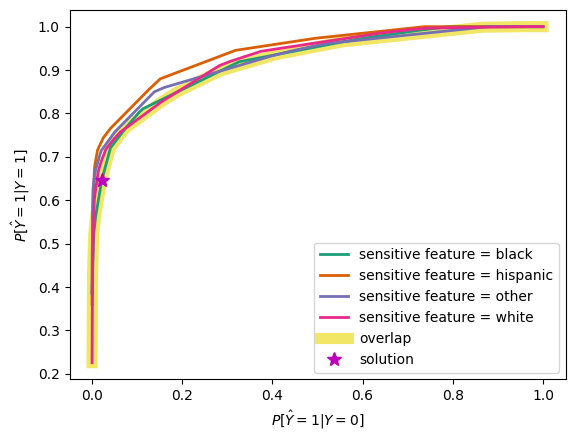



Updating threshold in post process stage
  Sensitive Group  Threshold 1  Probability of Using Threshold 1  Threshold 2  \
0           black         0.28                              0.02         0.27   
1        hispanic         0.28                              0.20         0.27   
2           other         0.28                              0.90         0.26   
3           white         0.29                              0.75         0.28   

   Probability of Using Threshold 2  
0                              0.98  
1                              0.80  
2                              0.10  
3                              0.25  


    f1   outcome imputation pre_process post_process model
0 0.25  ideation       iter   drop_race  thres_optim    rf
1 0.24  ideation       iter   drop_race  thres_optim    rf
      f1   outcome imputation pre_process post_process model
998 0.21  ideation       iter   drop_race  thres_optim    rf
999 0.27  ideation       iter   drop_race  thres_optim    rf

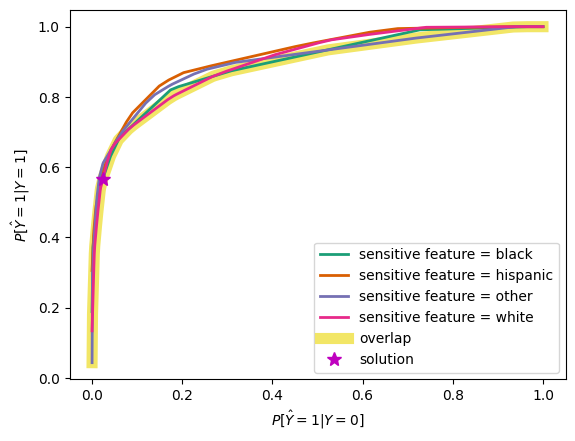



Updating threshold in post process stage
  Sensitive Group  Threshold 1  Probability of Using Threshold 1  Threshold 2  \
0           black         0.36                              0.69         0.29   
1        hispanic         0.40                              0.04         0.36   
2           other         0.36                              0.04         0.35   
3           white         0.38                              0.57         0.34   

   Probability of Using Threshold 2  
0                              0.31  
1                              0.96  
2                              0.96  
3                              0.43  


    f1   outcome imputation pre_process post_process model
0 0.25  ideation       iter   drop_race  thres_optim    rf
1 0.24  ideation       iter   drop_race  thres_optim    rf
       f1   outcome imputation pre_process post_process     model
2998 0.17  ideation       iter   drop_race  thres_optim  lightgbm
2999 0.22  ideation       iter   drop_race  thres_

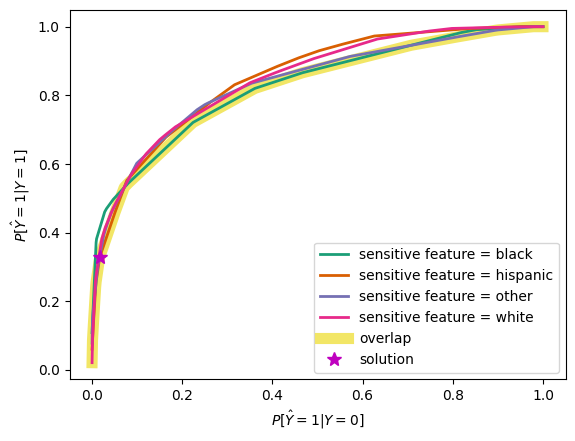



Updating threshold in post process stage
  Sensitive Group  Threshold 1  Probability of Using Threshold 1  Threshold 2  \
0           black         0.37                              0.58         0.32   
1        hispanic         0.38                              0.97         0.37   
2           other         0.39                              0.70         0.35   
3           white         0.43                              0.28         0.38   

   Probability of Using Threshold 2  
0                              0.42  
1                              0.03  
2                              0.30  
3                              0.72  


    f1   outcome imputation pre_process post_process model
0 0.25  ideation       iter   drop_race  thres_optim    rf
1 0.24  ideation       iter   drop_race  thres_optim    rf
       f1   outcome imputation pre_process post_process model
4998 0.17  ideation       iter   drop_race  thres_optim   xgb
4999 0.17  ideation       iter   drop_race  thres_optim   

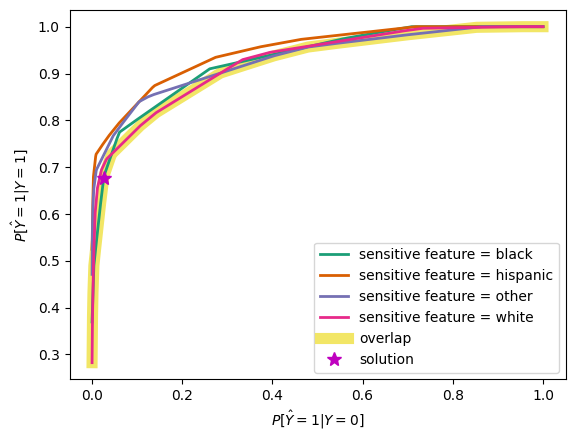



Updating threshold in post process stage
  Sensitive Group  Threshold 1  Probability of Using Threshold 1  Threshold 2  \
0           black         0.27                              0.93         0.27   
1        hispanic         0.27                              0.61         0.26   
2           other         0.28                              0.56         0.25   
3           white         0.29                              0.46         0.28   

   Probability of Using Threshold 2  
0                              0.07  
1                              0.39  
2                              0.44  
3                              0.54  


    f1   outcome imputation pre_process post_process model
0 0.25  ideation       iter   drop_race  thres_optim    rf
1 0.24  ideation       iter   drop_race  thres_optim    rf
       f1   outcome imputation    pre_process post_process model
6998 0.23  ideation       iter  class_weights  thres_optim    rf
6999 0.28  ideation       iter  class_weights  thres

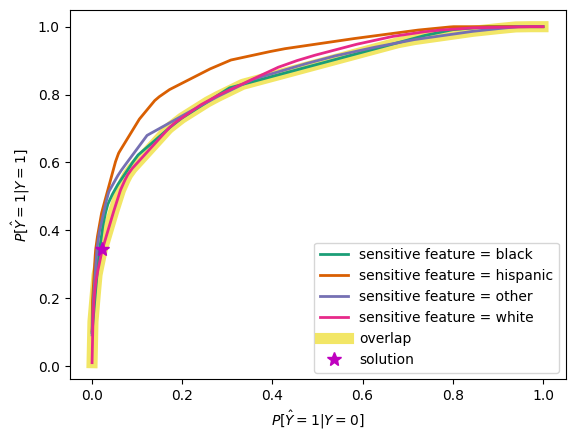



Updating threshold in post process stage
  Sensitive Group  Threshold 1  Probability of Using Threshold 1  Threshold 2  \
0           black         0.37                              0.56         0.36   
1        hispanic         0.36                              0.95         0.29   
2           other         0.36                              0.56         0.33   
3           white         0.41                              0.98         0.36   

   Probability of Using Threshold 2  
0                              0.44  
1                              0.05  
2                              0.44  
3                              0.02  


    f1   outcome imputation pre_process post_process model
0 0.25  ideation       iter   drop_race  thres_optim    rf
1 0.24  ideation       iter   drop_race  thres_optim    rf
       f1   outcome imputation    pre_process post_process     model
8998 0.14  ideation       iter  class_weights  thres_optim  lightgbm
8999 0.17  ideation       iter  class_weight

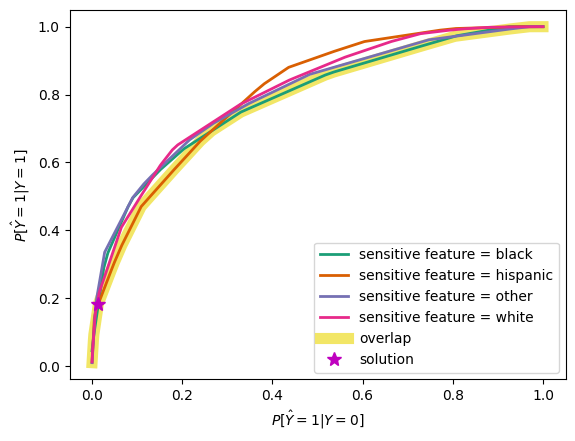



Updating threshold in post process stage
  Sensitive Group  Threshold 1  Probability of Using Threshold 1  Threshold 2  \
0           black         0.43                              0.54         0.34   
1        hispanic         0.37                              0.41         0.35   
2           other         0.38                              0.76         0.32   
3           white         0.44                              0.07         0.40   

   Probability of Using Threshold 2  
0                              0.46  
1                              0.59  
2                              0.24  
3                              0.93  


    f1   outcome imputation pre_process post_process model
0 0.25  ideation       iter   drop_race  thres_optim    rf
1 0.24  ideation       iter   drop_race  thres_optim    rf
        f1   outcome imputation    pre_process post_process model
10998 0.17  ideation       iter  class_weights  thres_optim   xgb
10999 0.25  ideation       iter  class_weights  th

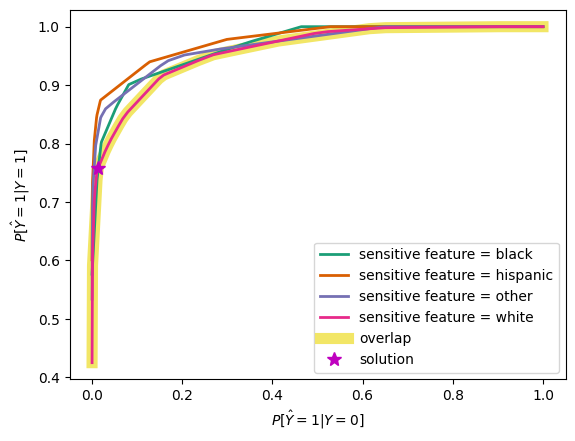



Updating threshold in post process stage
  Sensitive Group  Threshold 1  Probability of Using Threshold 1  Threshold 2  \
0           black         0.29                              0.69         0.27   
1        hispanic         0.27                              0.44         0.27   
2           other         0.28                              0.45         0.27   
3           white         0.29                              0.82         0.28   

   Probability of Using Threshold 2  
0                              0.31  
1                              0.56  
2                              0.55  
3                              0.18  


    f1   outcome imputation pre_process post_process model
0 0.25  ideation       iter   drop_race  thres_optim    rf
1 0.24  ideation       iter   drop_race  thres_optim    rf
        f1   outcome imputation pre_process post_process model
12998 0.22  ideation       iter        none  thres_optim    rf
12999 0.25  ideation       iter        none  thres_optim

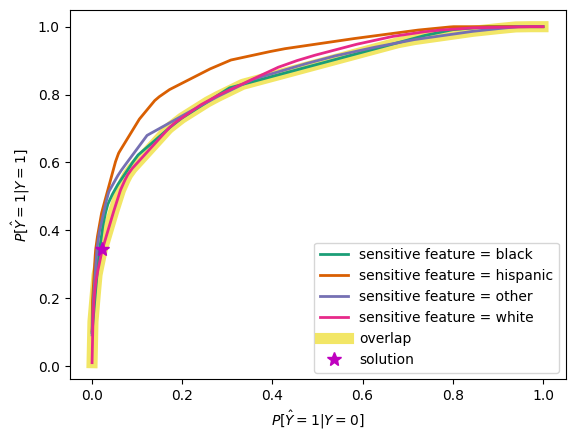



Updating threshold in post process stage
  Sensitive Group  Threshold 1  Probability of Using Threshold 1  Threshold 2  \
0           black         0.37                              0.56         0.36   
1        hispanic         0.36                              0.95         0.29   
2           other         0.36                              0.56         0.33   
3           white         0.41                              0.98         0.36   

   Probability of Using Threshold 2  
0                              0.44  
1                              0.05  
2                              0.44  
3                              0.02  


    f1   outcome imputation pre_process post_process model
0 0.25  ideation       iter   drop_race  thres_optim    rf
1 0.24  ideation       iter   drop_race  thres_optim    rf
        f1   outcome imputation pre_process post_process     model
14998 0.12  ideation       iter        none  thres_optim  lightgbm
14999 0.12  ideation       iter        none  thr

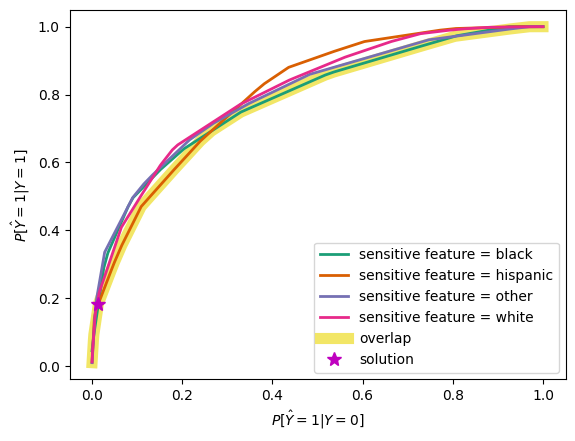



Updating threshold in post process stage
  Sensitive Group  Threshold 1  Probability of Using Threshold 1  Threshold 2  \
0           black         0.43                              0.54         0.34   
1        hispanic         0.37                              0.41         0.35   
2           other         0.38                              0.76         0.32   
3           white         0.44                              0.07         0.40   

   Probability of Using Threshold 2  
0                              0.46  
1                              0.59  
2                              0.24  
3                              0.93  


    f1   outcome imputation pre_process post_process model
0 0.25  ideation       iter   drop_race  thres_optim    rf
1 0.24  ideation       iter   drop_race  thres_optim    rf
        f1   outcome imputation pre_process post_process model
16998 0.14  ideation       iter        none  thres_optim   xgb
16999 0.19  ideation       iter        none  thres_optim

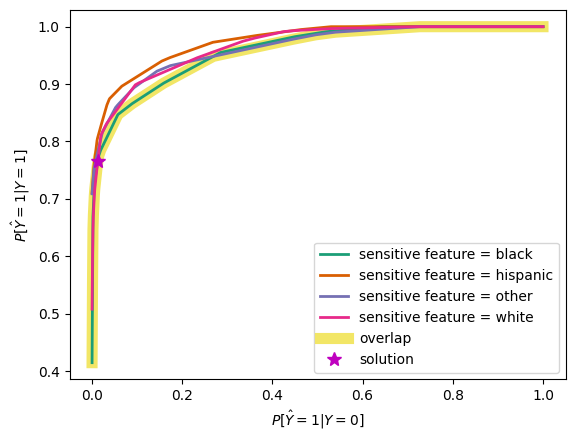



Updating threshold in post process stage
  Sensitive Group  Threshold 1  Probability of Using Threshold 1  Threshold 2  \
0           black         0.27                              0.48         0.27   
1        hispanic         0.28                              0.69         0.28   
2           other         0.29                              0.74         0.27   
3           white         0.30                              0.65         0.28   

   Probability of Using Threshold 2  
0                              0.52  
1                              0.31  
2                              0.26  
3                              0.35  


    f1   outcome imputation pre_process post_process model
0 0.25  ideation       iter   drop_race  thres_optim    rf
1 0.24  ideation       iter   drop_race  thres_optim    rf
        f1   outcome imputation pre_process post_process model
18998 0.19  ideation        knn   drop_race  thres_optim    rf
18999 0.23  ideation        knn   drop_race  thres_optim

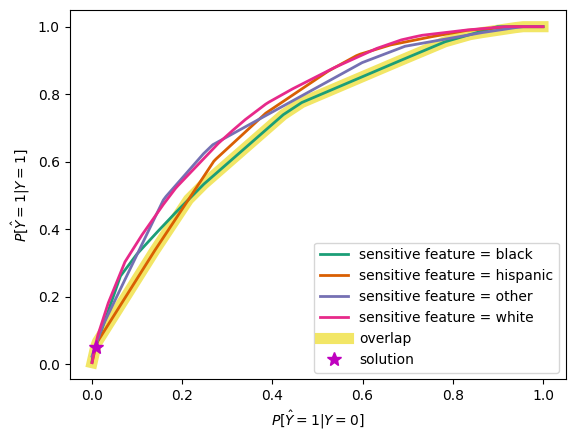



Updating threshold in post process stage
  Sensitive Group  Threshold 1  Probability of Using Threshold 1  Threshold 2  \
0           black         0.27                              0.93         0.23   
1        hispanic         0.30                              0.15         0.28   
2           other         0.29                              0.65         0.26   
3           white         0.29                              0.70         0.28   

   Probability of Using Threshold 2  
0                              0.07  
1                              0.85  
2                              0.35  
3                              0.30  


    f1   outcome imputation pre_process post_process model
0 0.25  ideation       iter   drop_race  thres_optim    rf
1 0.24  ideation       iter   drop_race  thres_optim    rf
        f1   outcome imputation pre_process post_process     model
20998 0.03  ideation        knn   drop_race  thres_optim  lightgbm
20999 0.02  ideation        knn   drop_race  thr

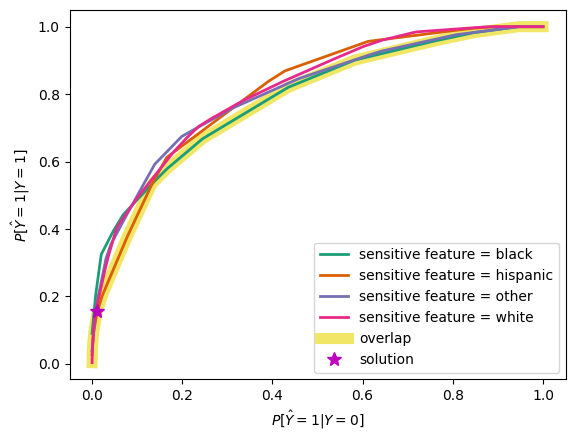



Updating threshold in post process stage
  Sensitive Group  Threshold 1  Probability of Using Threshold 1  Threshold 2  \
0           black         0.37                              0.64         0.33   
1        hispanic         0.38                              0.94         0.36   
2           other         0.41                              0.82         0.34   
3           white         0.42                              0.86         0.35   

   Probability of Using Threshold 2  
0                              0.36  
1                              0.06  
2                              0.18  
3                              0.14  


    f1   outcome imputation pre_process post_process model
0 0.25  ideation       iter   drop_race  thres_optim    rf
1 0.24  ideation       iter   drop_race  thres_optim    rf
        f1   outcome imputation pre_process post_process model
22998 0.13  ideation        knn   drop_race  thres_optim   xgb
22999 0.14  ideation        knn   drop_race  thres_optim

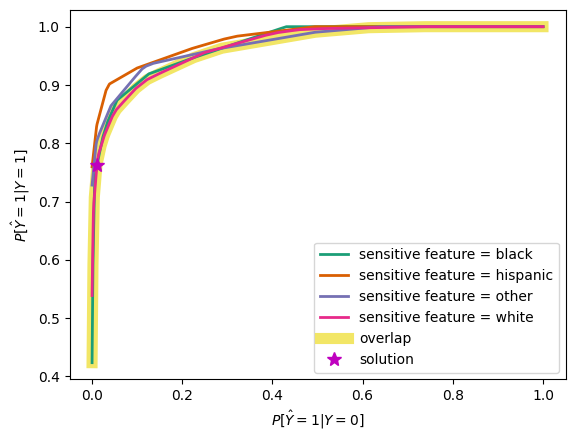



Updating threshold in post process stage
  Sensitive Group  Threshold 1  Probability of Using Threshold 1  Threshold 2  \
0           black         0.28                              0.88         0.26   
1        hispanic         0.28                              0.97         0.26   
2           other         0.28                              0.18         0.28   
3           white         0.31                              0.25         0.29   

   Probability of Using Threshold 2  
0                              0.12  
1                              0.03  
2                              0.82  
3                              0.75  


    f1   outcome imputation pre_process post_process model
0 0.25  ideation       iter   drop_race  thres_optim    rf
1 0.24  ideation       iter   drop_race  thres_optim    rf
        f1   outcome imputation    pre_process post_process model
24998 0.24  ideation        knn  class_weights  thres_optim    rf
24999 0.26  ideation        knn  class_weights  th

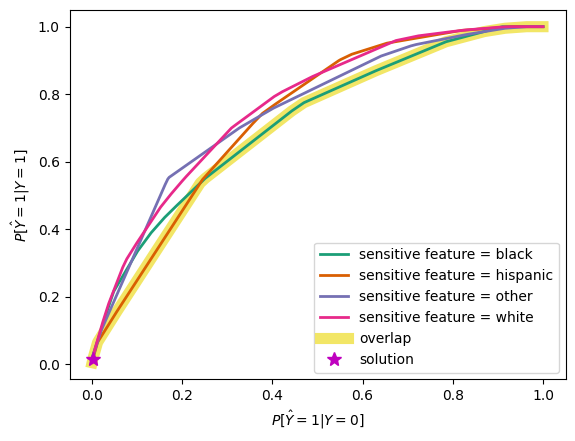



Updating threshold in post process stage
  Sensitive Group  Threshold 1  Probability of Using Threshold 1  Threshold 2  \
0           black         0.29                              0.99         0.27   
1        hispanic         0.27                              0.98         0.27   
2           other         0.30                              0.90         0.27   
3           white         0.31                              0.75         0.30   

   Probability of Using Threshold 2  
0                              0.01  
1                              0.02  
2                              0.10  
3                              0.25  


    f1   outcome imputation pre_process post_process model
0 0.25  ideation       iter   drop_race  thres_optim    rf
1 0.24  ideation       iter   drop_race  thres_optim    rf
        f1   outcome imputation    pre_process post_process     model
26998 0.00  ideation        knn  class_weights  thres_optim  lightgbm
26999 0.01  ideation        knn  class_wei

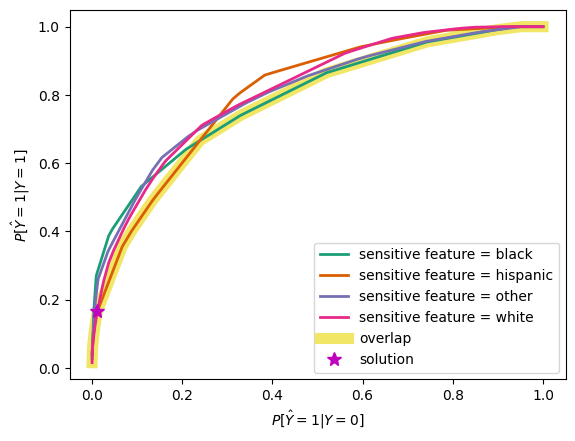



Updating threshold in post process stage
  Sensitive Group  Threshold 1  Probability of Using Threshold 1  Threshold 2  \
0           black         0.36                              0.90         0.31   
1        hispanic         0.36                              0.99         0.28   
2           other         0.38                              0.17         0.36   
3           white         0.42                              0.92         0.39   

   Probability of Using Threshold 2  
0                              0.10  
1                              0.01  
2                              0.83  
3                              0.08  


    f1   outcome imputation pre_process post_process model
0 0.25  ideation       iter   drop_race  thres_optim    rf
1 0.24  ideation       iter   drop_race  thres_optim    rf
        f1   outcome imputation    pre_process post_process model
28998 0.14  ideation        knn  class_weights  thres_optim   xgb
28999 0.18  ideation        knn  class_weights  th

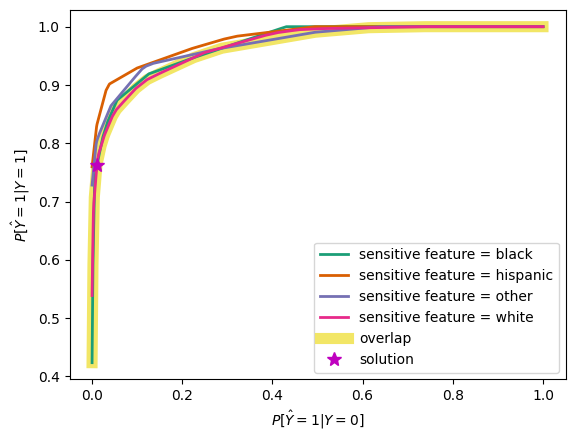



Updating threshold in post process stage
  Sensitive Group  Threshold 1  Probability of Using Threshold 1  Threshold 2  \
0           black         0.28                              0.88         0.26   
1        hispanic         0.28                              0.97         0.26   
2           other         0.28                              0.18         0.28   
3           white         0.31                              0.25         0.29   

   Probability of Using Threshold 2  
0                              0.12  
1                              0.03  
2                              0.82  
3                              0.75  


    f1   outcome imputation pre_process post_process model
0 0.25  ideation       iter   drop_race  thres_optim    rf
1 0.24  ideation       iter   drop_race  thres_optim    rf
        f1   outcome imputation pre_process post_process model
30998 0.25  ideation        knn        none  thres_optim    rf
30999 0.27  ideation        knn        none  thres_optim

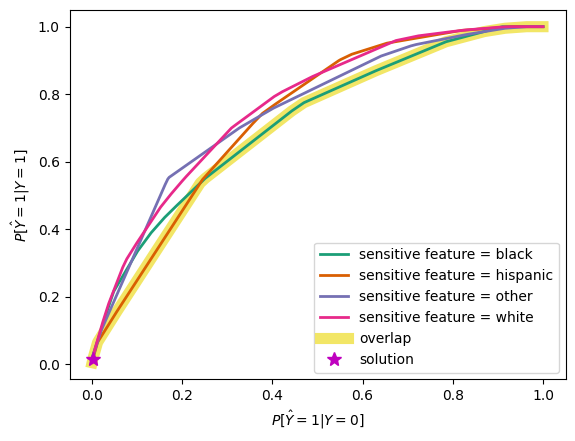



Updating threshold in post process stage
  Sensitive Group  Threshold 1  Probability of Using Threshold 1  Threshold 2  \
0           black         0.29                              0.99         0.27   
1        hispanic         0.27                              0.98         0.27   
2           other         0.30                              0.90         0.27   
3           white         0.31                              0.75         0.30   

   Probability of Using Threshold 2  
0                              0.01  
1                              0.02  
2                              0.10  
3                              0.25  


    f1   outcome imputation pre_process post_process model
0 0.25  ideation       iter   drop_race  thres_optim    rf
1 0.24  ideation       iter   drop_race  thres_optim    rf
        f1   outcome imputation pre_process post_process     model
32998 0.00  ideation        knn        none  thres_optim  lightgbm
32999 0.01  ideation        knn        none  thr

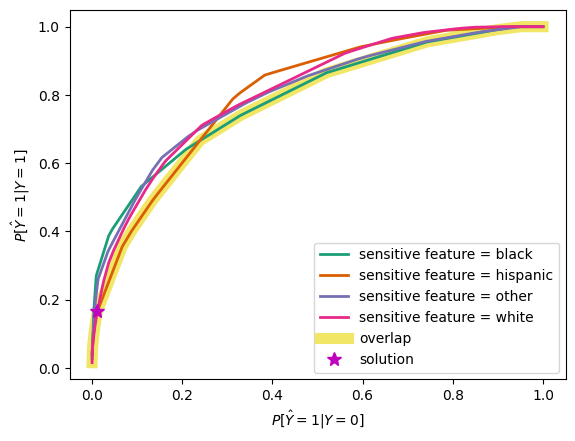



Updating threshold in post process stage
  Sensitive Group  Threshold 1  Probability of Using Threshold 1  Threshold 2  \
0           black         0.36                              0.90         0.31   
1        hispanic         0.36                              0.99         0.28   
2           other         0.38                              0.17         0.36   
3           white         0.42                              0.92         0.39   

   Probability of Using Threshold 2  
0                              0.10  
1                              0.01  
2                              0.83  
3                              0.08  


    f1   outcome imputation pre_process post_process model
0 0.25  ideation       iter   drop_race  thres_optim    rf
1 0.24  ideation       iter   drop_race  thres_optim    rf
        f1   outcome imputation pre_process post_process model
34998 0.11  ideation        knn        none  thres_optim   xgb
34999 0.12  ideation        knn        none  thres_optim

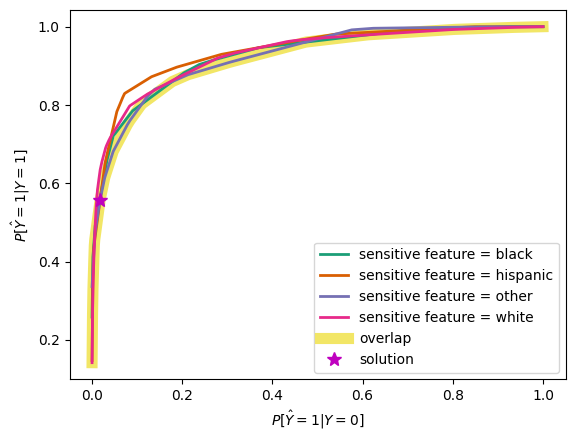



Updating threshold in post process stage
  Sensitive Group  Threshold 1  Probability of Using Threshold 1  Threshold 2  \
0           black         0.38                              0.57         0.30   
1        hispanic         0.53                              0.48         0.39   
2           other         0.41                              0.86         0.37   
3           white         0.38                              1.00         0.37   

   Probability of Using Threshold 2  
0                              0.43  
1                              0.52  
2                              0.14  
3                              0.00  


    f1   outcome imputation pre_process post_process model
0 0.25  ideation       iter   drop_race  thres_optim    rf
1 0.24  ideation       iter   drop_race  thres_optim    rf
        f1          outcome imputation pre_process post_process model
36998 0.38  suicideatt_qn29       iter   drop_race  thres_optim    rf
36999 0.34  suicideatt_qn29       iter   d

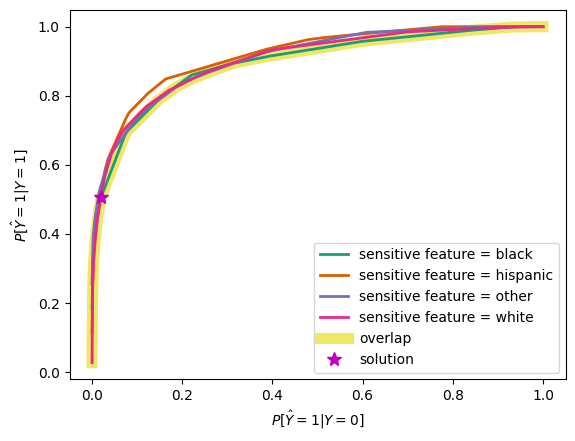



Updating threshold in post process stage
  Sensitive Group  Threshold 1  Probability of Using Threshold 1  Threshold 2  \
0           black         0.34                              1.00         0.22   
1        hispanic         0.58                              0.40         0.45   
2           other         0.41                              0.96         0.36   
3           white         0.47                              0.40         0.41   

   Probability of Using Threshold 2  
0                              0.00  
1                              0.60  
2                              0.04  
3                              0.60  


    f1   outcome imputation pre_process post_process model
0 0.25  ideation       iter   drop_race  thres_optim    rf
1 0.24  ideation       iter   drop_race  thres_optim    rf
        f1          outcome imputation pre_process post_process     model
38998 0.36  suicideatt_qn29       iter   drop_race  thres_optim  lightgbm
38999 0.32  suicideatt_qn29       

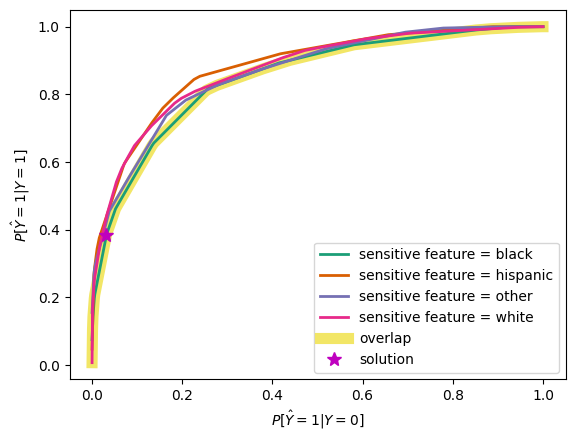



Updating threshold in post process stage
  Sensitive Group  Threshold 1  Probability of Using Threshold 1  Threshold 2  \
0           black         0.49                              0.01         0.33   
1        hispanic         0.54                              0.78         0.35   
2           other         0.55                              0.16         0.40   
3           white         0.40                              0.99         0.33   

   Probability of Using Threshold 2  
0                              0.99  
1                              0.22  
2                              0.84  
3                              0.01  


    f1   outcome imputation pre_process post_process model
0 0.25  ideation       iter   drop_race  thres_optim    rf
1 0.24  ideation       iter   drop_race  thres_optim    rf
        f1          outcome imputation pre_process post_process model
40998 0.40  suicideatt_qn29       iter   drop_race  thres_optim   xgb
40999 0.35  suicideatt_qn29       iter   d

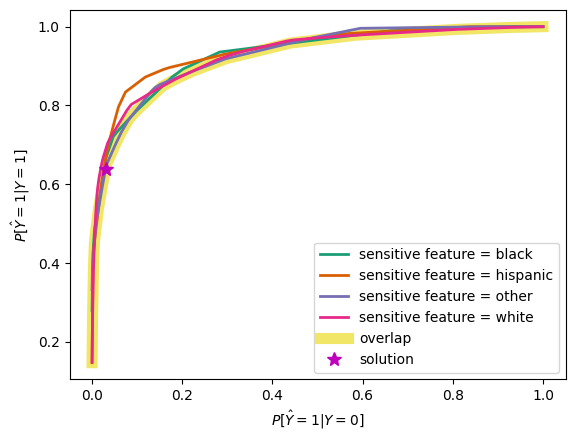



Updating threshold in post process stage
  Sensitive Group  Threshold 1  Probability of Using Threshold 1  Threshold 2  \
0           black         0.39                              0.02         0.31   
1        hispanic         0.41                              0.33         0.37   
2           other         0.40                              0.00         0.37   
3           white         0.34                              0.33         0.31   

   Probability of Using Threshold 2  
0                              0.98  
1                              0.67  
2                              1.00  
3                              0.67  


    f1   outcome imputation pre_process post_process model
0 0.25  ideation       iter   drop_race  thres_optim    rf
1 0.24  ideation       iter   drop_race  thres_optim    rf
        f1          outcome imputation    pre_process post_process model
42998 0.41  suicideatt_qn29       iter  class_weights  thres_optim    rf
42999 0.37  suicideatt_qn29       it

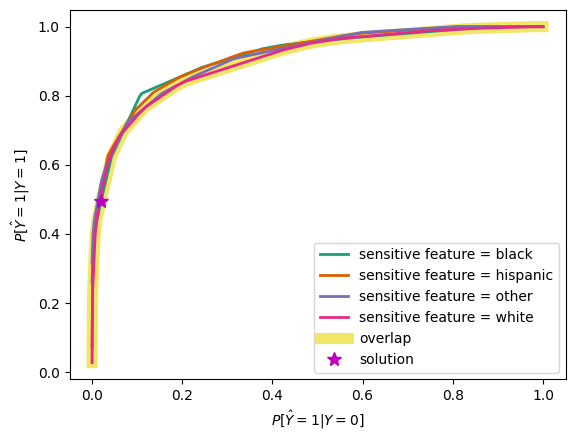



Updating threshold in post process stage
  Sensitive Group  Threshold 1  Probability of Using Threshold 1  Threshold 2  \
0           black         0.40                              0.99         0.30   
1        hispanic         0.50                              0.86         0.41   
2           other         0.46                              0.26         0.44   
3           white         0.41                              0.06         0.41   

   Probability of Using Threshold 2  
0                              0.01  
1                              0.14  
2                              0.74  
3                              0.94  


    f1   outcome imputation pre_process post_process model
0 0.25  ideation       iter   drop_race  thres_optim    rf
1 0.24  ideation       iter   drop_race  thres_optim    rf
        f1          outcome imputation    pre_process post_process     model
44998 0.35  suicideatt_qn29       iter  class_weights  thres_optim  lightgbm
44999 0.34  suicideatt_qn29 

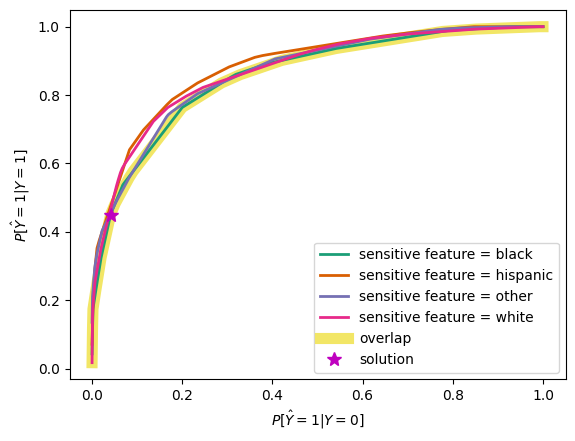



Updating threshold in post process stage
  Sensitive Group  Threshold 1  Probability of Using Threshold 1  Threshold 2  \
0           black         0.37                              0.02         0.30   
1        hispanic         0.57                              0.55         0.32   
2           other         0.48                              0.32         0.38   
3           white         0.42                              0.41         0.32   

   Probability of Using Threshold 2  
0                              0.98  
1                              0.45  
2                              0.68  
3                              0.59  


    f1   outcome imputation pre_process post_process model
0 0.25  ideation       iter   drop_race  thres_optim    rf
1 0.24  ideation       iter   drop_race  thres_optim    rf
        f1          outcome imputation    pre_process post_process model
46998 0.39  suicideatt_qn29       iter  class_weights  thres_optim   xgb
46999 0.33  suicideatt_qn29       it

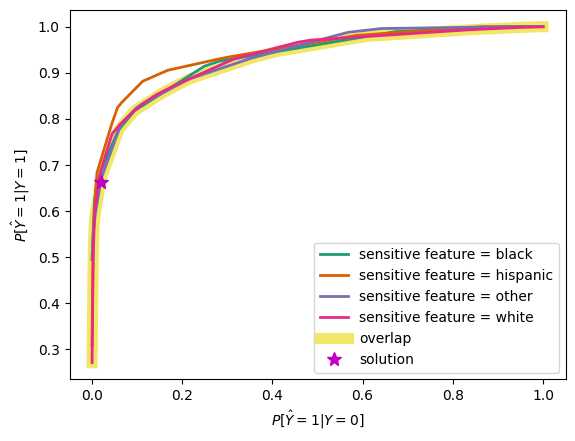



Updating threshold in post process stage
  Sensitive Group  Threshold 1  Probability of Using Threshold 1  Threshold 2  \
0           black         0.34                              0.09         0.32   
1        hispanic         0.42                              0.69         0.35   
2           other         0.44                              0.01         0.38   
3           white         0.38                              0.00         0.35   

   Probability of Using Threshold 2  
0                              0.91  
1                              0.31  
2                              0.99  
3                              1.00  


    f1   outcome imputation pre_process post_process model
0 0.25  ideation       iter   drop_race  thres_optim    rf
1 0.24  ideation       iter   drop_race  thres_optim    rf
        f1          outcome imputation pre_process post_process model
48998 0.40  suicideatt_qn29       iter        none  thres_optim    rf
48999 0.36  suicideatt_qn29       iter    

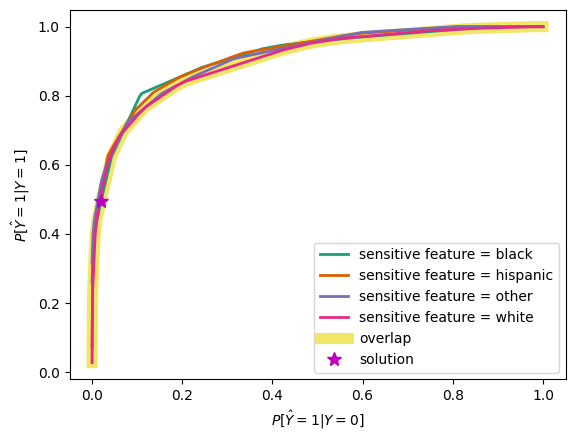



Updating threshold in post process stage
  Sensitive Group  Threshold 1  Probability of Using Threshold 1  Threshold 2  \
0           black         0.40                              0.99         0.30   
1        hispanic         0.50                              0.86         0.41   
2           other         0.46                              0.26         0.44   
3           white         0.41                              0.06         0.41   

   Probability of Using Threshold 2  
0                              0.01  
1                              0.14  
2                              0.74  
3                              0.94  


    f1   outcome imputation pre_process post_process model
0 0.25  ideation       iter   drop_race  thres_optim    rf
1 0.24  ideation       iter   drop_race  thres_optim    rf
        f1          outcome imputation pre_process post_process     model
50998 0.36  suicideatt_qn29       iter        none  thres_optim  lightgbm
50999 0.37  suicideatt_qn29       

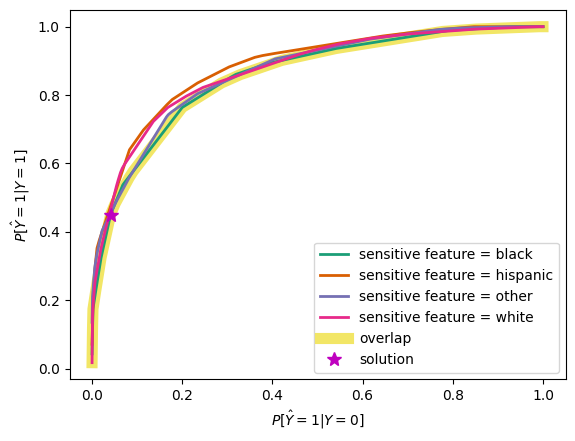



Updating threshold in post process stage
  Sensitive Group  Threshold 1  Probability of Using Threshold 1  Threshold 2  \
0           black         0.37                              0.02         0.30   
1        hispanic         0.57                              0.55         0.32   
2           other         0.48                              0.32         0.38   
3           white         0.42                              0.41         0.32   

   Probability of Using Threshold 2  
0                              0.98  
1                              0.45  
2                              0.68  
3                              0.59  


    f1   outcome imputation pre_process post_process model
0 0.25  ideation       iter   drop_race  thres_optim    rf
1 0.24  ideation       iter   drop_race  thres_optim    rf
        f1          outcome imputation pre_process post_process model
52998 0.37  suicideatt_qn29       iter        none  thres_optim   xgb
52999 0.33  suicideatt_qn29       iter    

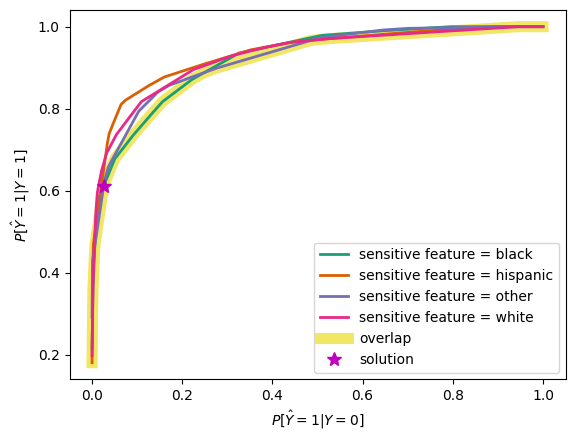



Updating threshold in post process stage
  Sensitive Group  Threshold 1  Probability of Using Threshold 1  Threshold 2  \
0           black         0.34                              0.68         0.27   
1        hispanic         0.53                              0.24         0.38   
2           other         0.52                              0.05         0.38   
3           white         0.37                              0.46         0.34   

   Probability of Using Threshold 2  
0                              0.32  
1                              0.76  
2                              0.95  
3                              0.54  


    f1   outcome imputation pre_process post_process model
0 0.25  ideation       iter   drop_race  thres_optim    rf
1 0.24  ideation       iter   drop_race  thres_optim    rf
        f1          outcome imputation pre_process post_process model
54998 0.39  suicideatt_qn29        knn   drop_race  thres_optim    rf
54999 0.38  suicideatt_qn29        knn   d

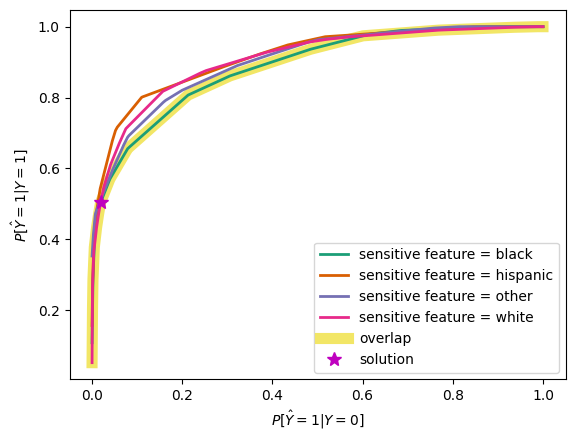



Updating threshold in post process stage
  Sensitive Group  Threshold 1  Probability of Using Threshold 1  Threshold 2  \
0           black         0.34                              0.86         0.29   
1        hispanic         0.49                              0.95         0.37   
2           other         0.44                              0.80         0.34   
3           white         0.42                              0.95         0.40   

   Probability of Using Threshold 2  
0                              0.14  
1                              0.05  
2                              0.20  
3                              0.05  


    f1   outcome imputation pre_process post_process model
0 0.25  ideation       iter   drop_race  thres_optim    rf
1 0.24  ideation       iter   drop_race  thres_optim    rf
        f1          outcome imputation pre_process post_process     model
56998 0.38  suicideatt_qn29        knn   drop_race  thres_optim  lightgbm
56999 0.35  suicideatt_qn29       

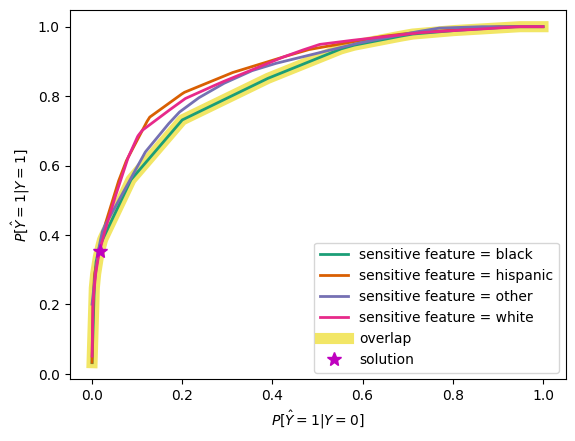



Updating threshold in post process stage
  Sensitive Group  Threshold 1  Probability of Using Threshold 1  Threshold 2  \
0           black         0.34                              0.77         0.33   
1        hispanic         0.65                              0.57         0.51   
2           other         0.49                              0.16         0.49   
3           white         0.49                              0.15         0.47   

   Probability of Using Threshold 2  
0                              0.23  
1                              0.43  
2                              0.84  
3                              0.85  


    f1   outcome imputation pre_process post_process model
0 0.25  ideation       iter   drop_race  thres_optim    rf
1 0.24  ideation       iter   drop_race  thres_optim    rf
        f1          outcome imputation pre_process post_process model
58998 0.33  suicideatt_qn29        knn   drop_race  thres_optim   xgb
58999 0.29  suicideatt_qn29        knn   d

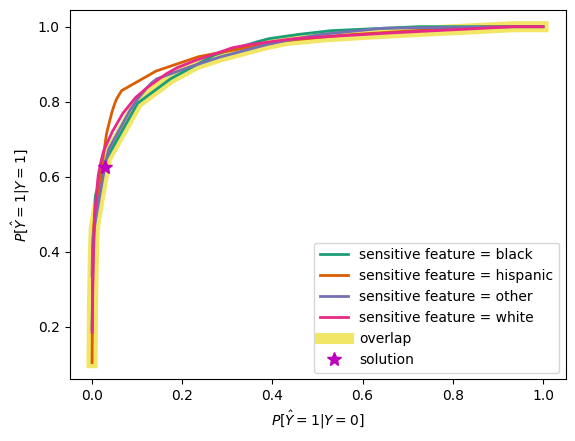



Updating threshold in post process stage
  Sensitive Group  Threshold 1  Probability of Using Threshold 1  Threshold 2  \
0           black         0.38                              0.11         0.32   
1        hispanic         0.50                              0.17         0.39   
2           other         0.46                              0.01         0.39   
3           white         0.35                              0.88         0.32   

   Probability of Using Threshold 2  
0                              0.89  
1                              0.83  
2                              0.99  
3                              0.12  


    f1   outcome imputation pre_process post_process model
0 0.25  ideation       iter   drop_race  thres_optim    rf
1 0.24  ideation       iter   drop_race  thres_optim    rf
        f1          outcome imputation    pre_process post_process model
60998 0.40  suicideatt_qn29        knn  class_weights  thres_optim    rf
60999 0.38  suicideatt_qn29        k

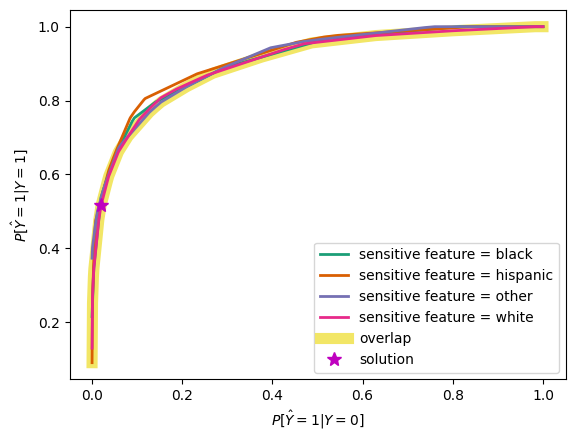



Updating threshold in post process stage
  Sensitive Group  Threshold 1  Probability of Using Threshold 1  Threshold 2  \
0           black         0.36                              0.99         0.29   
1        hispanic         0.55                              0.67         0.40   
2           other         0.48                              0.31         0.43   
3           white         0.39                              0.97         0.36   

   Probability of Using Threshold 2  
0                              0.01  
1                              0.33  
2                              0.69  
3                              0.03  


    f1   outcome imputation pre_process post_process model
0 0.25  ideation       iter   drop_race  thres_optim    rf
1 0.24  ideation       iter   drop_race  thres_optim    rf
        f1          outcome imputation    pre_process post_process     model
62998 0.37  suicideatt_qn29        knn  class_weights  thres_optim  lightgbm
62999 0.32  suicideatt_qn29 

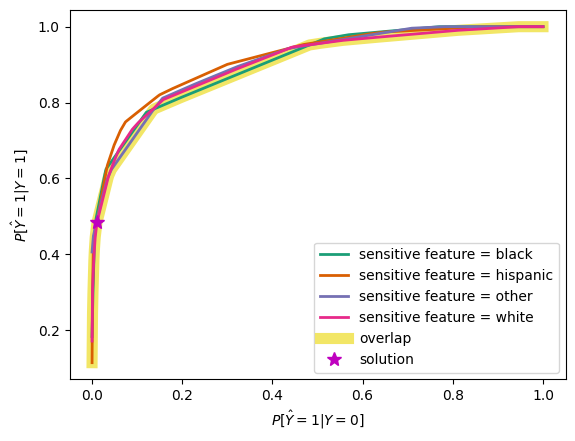



Updating threshold in post process stage
  Sensitive Group  Threshold 1  Probability of Using Threshold 1  Threshold 2  \
0           black         0.38                              0.86         0.32   
1        hispanic         0.53                              0.91         0.39   
2           other         0.53                              0.52         0.44   
3           white         0.43                              0.99         0.34   

   Probability of Using Threshold 2  
0                              0.14  
1                              0.09  
2                              0.48  
3                              0.01  


    f1   outcome imputation pre_process post_process model
0 0.25  ideation       iter   drop_race  thres_optim    rf
1 0.24  ideation       iter   drop_race  thres_optim    rf
        f1          outcome imputation    pre_process post_process model
64998 0.33  suicideatt_qn29        knn  class_weights  thres_optim   xgb
64999 0.32  suicideatt_qn29        k

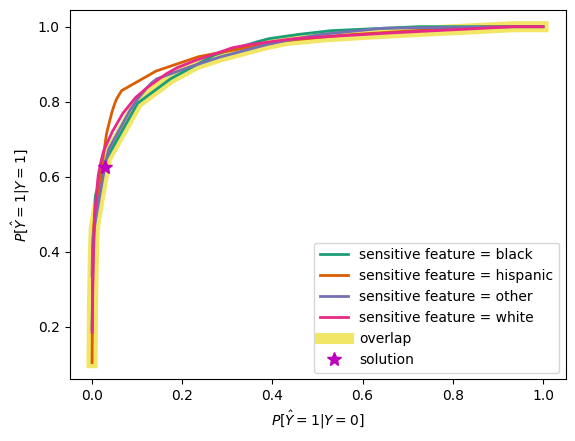



Updating threshold in post process stage
  Sensitive Group  Threshold 1  Probability of Using Threshold 1  Threshold 2  \
0           black         0.38                              0.11         0.32   
1        hispanic         0.50                              0.17         0.39   
2           other         0.46                              0.01         0.39   
3           white         0.35                              0.88         0.32   

   Probability of Using Threshold 2  
0                              0.89  
1                              0.83  
2                              0.99  
3                              0.12  


    f1   outcome imputation pre_process post_process model
0 0.25  ideation       iter   drop_race  thres_optim    rf
1 0.24  ideation       iter   drop_race  thres_optim    rf
        f1          outcome imputation pre_process post_process model
66998 0.40  suicideatt_qn29        knn        none  thres_optim    rf
66999 0.39  suicideatt_qn29        knn    

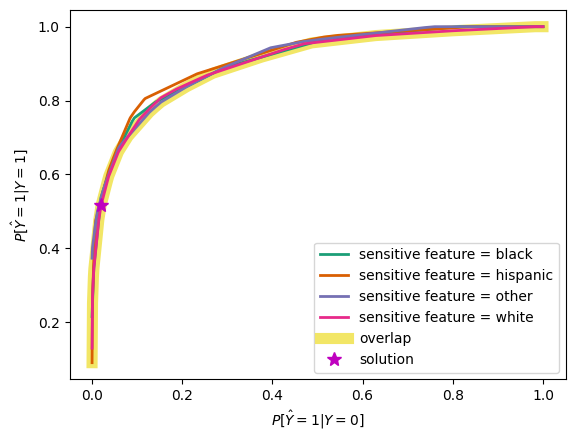



Updating threshold in post process stage
  Sensitive Group  Threshold 1  Probability of Using Threshold 1  Threshold 2  \
0           black         0.36                              0.99         0.29   
1        hispanic         0.55                              0.67         0.40   
2           other         0.48                              0.31         0.43   
3           white         0.39                              0.97         0.36   

   Probability of Using Threshold 2  
0                              0.01  
1                              0.33  
2                              0.69  
3                              0.03  


    f1   outcome imputation pre_process post_process model
0 0.25  ideation       iter   drop_race  thres_optim    rf
1 0.24  ideation       iter   drop_race  thres_optim    rf
        f1          outcome imputation pre_process post_process     model
68998 0.34  suicideatt_qn29        knn        none  thres_optim  lightgbm
68999 0.29  suicideatt_qn29       

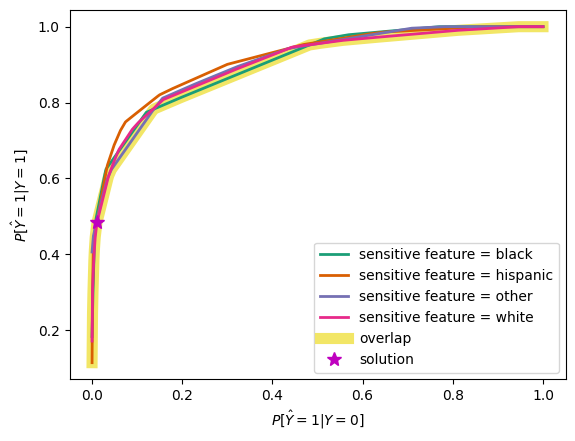



Updating threshold in post process stage
  Sensitive Group  Threshold 1  Probability of Using Threshold 1  Threshold 2  \
0           black         0.38                              0.86         0.32   
1        hispanic         0.53                              0.91         0.39   
2           other         0.53                              0.52         0.44   
3           white         0.43                              0.99         0.34   

   Probability of Using Threshold 2  
0                              0.14  
1                              0.09  
2                              0.48  
3                              0.01  


    f1   outcome imputation pre_process post_process model
0 0.25  ideation       iter   drop_race  thres_optim    rf
1 0.24  ideation       iter   drop_race  thres_optim    rf
        f1          outcome imputation pre_process post_process model
70998 0.31  suicideatt_qn29        knn        none  thres_optim   xgb
70999 0.30  suicideatt_qn29        knn    

In [ ]:
outcomes = ['ideation','suicideatt_qn29']
imputations = ['iter', "knn"]
models = ["rf","lightgbm", "xgb"]
pre_process = ["drop_race", "class_weights", "none"]
post_process = ['thres_optim', "none"]
demographics = ['grade', 'race_eth_copy', 'sexuality']
weight = "weight"

mi_threshold = 0.25
test_split = 0.20 # This split finds a 70/30 split
n_trials  = 5

SEED = 123
random.seed(SEED)
np.random.seed(SEED)

n_boots = 1000

model_df_loop = model_df.copy()

metrics = [
    ("AUCROC", wf_auc_full, bf_auc_full, hf_auc_full, of_auc_full),
    ("AURPRC", wf_ap_full, bf_ap_full, hf_ap_full, of_ap_full),
    ("Brier", wf_brier_full, bf_brier_full, hf_brier_full, of_brier_full),
    ("F1", wf_f1_full, bf_f1_full, hf_f1_full, of_f1_full),
    ("Accuracy", wf_acc_full, bf_acc_full, hf_acc_full, of_acc_full),
    ("Precision", wf_prec_full, bf_prec_full, hf_prec_full, of_prec_full),
    ("Recall", wf_rec_full, bf_rec_full, hf_rec_full, of_rec_full),
]

groups = ["is_wf", "is_bf", "is_hf", "is_of"]

overall_model_metrics = []
race_model_metrics_df = []
raw_race_model_dist = []
full_dist_df = []
threshold_optim = []
data_split_dists = []
data_dict = {}
model_dict = {}

feature_selection_process = []

for out in range(len(outcomes)):

  Y_var = outcomes[out]

  X_vars = model_df_loop.drop(columns = outcomes + ['weight'] + demographics + sample_design).columns

  cols = [Y_var] + X_vars.tolist() + demographics + [weight] + sample_design

  model_df_loop = model_df_loop.dropna(subset=[Y_var, "race_eth_copy", weight, "PSU", "stratum"])

  train_idx, test_idx = survey_train_test_split(
      strata=model_df_loop ['stratum'], clusters=model_df_loop['PSU'], test_size=test_split, random_state=SEED
    )

  train, test = model_df_loop.iloc[train_idx], model_df_loop.iloc[test_idx]

  strata_train, psu_train = train['stratum'], train['PSU']
  strata_test, psu_test = test['stratum'], test['PSU']
  train_schools, test_schools = set(psu_train), set(psu_test)

  print(f'outcome ---> {Y_var} Train: {len(train):,} rows / {len(train_schools)} schools | '
      f'Test: {len(test):,} rows / {len(test_schools)} schools')

  print('No school in both sides:', 'for outcome', Y_var, ":", train_schools.isdisjoint(test_schools))

  print('for outcome', Y_var,"Test Ratio", round(len(test) / (len(test) + len(train)), 2))

  print("\n")

  X_train = pd.get_dummies(train.loc[:, X_vars].reset_index(drop=True), columns=['sexual_partners'], drop_first=True)
  X_train = X_train.drop(columns= "race4")

  X_test  = pd.get_dummies(test.loc[:, X_vars].reset_index(drop=True), columns=['sexual_partners'], drop_first=True)
  X_test = X_test.drop(columns= "race4")

  X_train_demo = pd.get_dummies(train.loc[:, demographics].reset_index(drop=True), drop_first=True)
  X_test_demo = pd.get_dummies(test.loc[:, demographics].reset_index(drop=True), drop_first=True)

  y_train = train.loc[:, Y_var].reset_index(drop=True)
  y_test  = test.loc[:, Y_var].reset_index(drop=True)

  r_train = train.loc[:, 'race4']
  r_test = test.loc[:, 'race4']

  w_train = train.loc[:, 'weight'].reset_index(drop=True)
  w_test  = test.loc[:,  'weight'].reset_index(drop=True)

  X_feature_names = X_train.columns
  X_demographics_names = X_train_demo.columns


  is_wf = (np.array(r_train) == "white")
  is_bf = (np.array(r_train) == "black")
  is_hf = (np.array(r_train) == "hispanic")
  is_of = (np.array(r_train) == "other")

  train_dist = pd.DataFrame({
      "training_set": [f"White females: {is_wf.sum()} rows across {len(np.unique(psu_train[is_wf]))} schools",
                       f"Black females: {is_bf.sum()} rows across {len(np.unique(psu_train[is_bf]))} schools",
                       f"Hispanic females: {is_hf.sum()} rows across {len(np.unique(psu_train[is_hf]))} schools",
                       f"Other females: {is_of.sum()} rows across {len(np.unique(psu_train[is_of]))} schools"]
      })

  is_wf = (np.array(r_test) == "white")
  is_bf = (np.array(r_test) == "black")
  is_hf = (np.array(r_test) == "hispanic")
  is_of = (np.array(r_test) == "other")


  test_dist = pd.DataFrame({
       "testing_set": [f"White females: {is_wf.sum()} rows across {len(np.unique(psu_test[is_wf]))} schools",
                       f"Black females: {is_bf.sum()} rows across {len(np.unique(psu_test[is_bf]))} schools",
                       f"Hispanic females: {is_hf.sum()} rows across {len(np.unique(psu_test[is_hf]))} schools",
                       f"Other females: {is_of.sum()} rows across {len(np.unique(psu_test[is_of]))} schools"]
       })

  complete_dist = pd.concat([train_dist, test_dist], axis=1)

  complete_dist['outcome'] = Y_var

  data_split_dists.append(complete_dist)

  for imp in range(len(imputations)):

    print("Imp Method:", imputations[imp])


    if imputations[imp] == "iter":

       imputer = IterativeImputer(max_iter=20,
                                  random_state=SEED,
                                  initial_strategy="median",
                                  imputation_order="ascending",
                                  skip_complete=True)

    else:
      imputer = KNNImputer(n_neighbors=3, weights="uniform")

    X_train_imp = X_train.copy()
    X_test_imp = X_test.copy()

    X_train_imp = imputer.fit_transform(X_train_imp)
    X_test_imp = imputer.transform(X_test_imp)

    X_train_imp = pd.DataFrame(X_train_imp, columns =  X_feature_names)
    X_test_imp = pd.DataFrame(X_test_imp, columns =  X_feature_names)

    X_train_imp = X_train_imp.apply(lambda col: (col >= 0.5).astype(int))
    X_test_imp = X_test_imp.apply(lambda col: (col >= 0.5).astype(int))

    # Feature selecting process
    # Stage 1: Getting the initial MI and VIF scores

    # --- MI ----
    mi_scores = mutual_info_classif(X_train_imp, y_train, discrete_features=True, random_state=SEED)

    mi_df = pd.DataFrame({
        'feature': X_feature_names,
        'MI_score': mi_scores
        })

    mi_df['percentile'] = mi_df['MI_score'].rank(pct=True)

    # --- VIF ----
    vif_df = pd.DataFrame()

    vif_df["feature"] = X_train_imp.columns

    vif_df["VIF"] = [ variance_inflation_factor(X_train_imp.values, i)
    for i in range(X_train_imp.shape[1])
     ]

    vif_df["category"] = vif_df["VIF"].apply(vif_category)

    feature_df_before = pd.merge(mi_df, vif_df, on='feature').sort_values(by='MI_score', ascending=False)

    feature_df_before['outcome'] = Y_var
    feature_df_before['imputation'] = imputations[imp]

    print("\n\n")
    print("Before dropping MI below", mi_threshold, "percentile")

    print(feature_df_before.head())

    feature_df_dropped_mi = feature_df_before[feature_df_before['percentile'] >= mi_threshold].drop(columns= ['VIF', 'category'])

    mi_keep = feature_df_dropped_mi['feature'].tolist()

    mi_dropped = feature_df_before[feature_df_before['percentile'] < mi_threshold].drop(columns= ['VIF', 'category'])['feature'].tolist()

    X_train_imp = X_train_imp[mi_keep]

    # Stage 2: Recompute VIF after dropping MI
    # --- VIF ---
    vif_df = pd.DataFrame()

    vif_df["feature"] = X_train_imp.columns

    vif_df["VIF"] = [
        variance_inflation_factor(X_train_imp.values, i)
         for i in range(X_train_imp.shape[1])
      ]

    vif_df["category"] = vif_df["VIF"].apply(vif_category)

    feature_df_dropped_mi = pd.merge(feature_df_dropped_mi, vif_df, on='feature').sort_values(by='MI_score', ascending=False)

    print("\n\n")

    print("After dropping MI below", mi_threshold, "percentile")
    print("Dropped Variables on MI", mi_dropped)

    # Stage 3: Recompute VIF score to make sure they all stay under 10 VIF
    feature_df_dropped_mi_and_vif = feature_df_dropped_mi[feature_df_dropped_mi['category'] == "VIF < 10"].drop(columns= ['VIF', 'category']) # Selecting variables that are below VIF of 10

    vif_keep = feature_df_dropped_mi_and_vif['feature'].tolist()
    vif_drop  = feature_df_dropped_mi[feature_df_dropped_mi['category'] != "VIF < 10"].drop(columns= ['VIF', 'category'])['feature'].tolist()

    X_train_imp = X_train_imp[vif_keep]
    X_test_imp = X_test_imp[vif_keep]

    vif_df = pd.DataFrame()

    vif_df["feature"] = X_train_imp.columns

    vif_df["VIF"] = [
          variance_inflation_factor(X_train_imp.values, i)
          for i in range(X_train_imp.shape[1])
          ]

    vif_df["category"] = vif_df["VIF"].apply(vif_category)

    feature_df_dropped_mi_and_vif = pd.merge(feature_df_dropped_mi_and_vif, vif_df, on='feature').sort_values(by='MI_score', ascending=False)

    feature_df_before['stage'] = "step 1"
    feature_df_dropped_mi['stage'] = "step 2"
    feature_df_dropped_mi_and_vif['stage'] = "step 3"

    combinded_feature_eda = pd.concat([feature_df_before, feature_df_dropped_mi, feature_df_dropped_mi_and_vif])

    feature_selection_process.append(combinded_feature_eda) 

    print("\n\n")

    print("After dropping MI below", mi_threshold, "percentile", "and VIF > 10")
    print("Dropped Variables on VIF", vif_drop)

    print("\n\n")

    print("---Feature Names---")
    print(X_train_imp.columns)

    print("\n\n")

    print("---Demographics---")
    print(X_train_demo.columns)

    full_features = X_train_imp.columns.tolist() + X_train_demo.columns.tolist()

    X_train_imp_full = pd.concat([X_train_imp, X_train_demo.astype(int)], axis=1)
    X_test_imp_full = pd.concat([X_test_imp, X_test_demo.astype(int)], axis=1)


    print("\n\n")

    for pre in range(len(pre_process)):


      if pre_process[pre] == "class_weights":

        X_train_imp_full_pre =  X_train_imp_full.copy()
        X_test_imp_full_pre =  X_test_imp_full.copy()
        y_train_pre = y_train.copy()

        classes = np.unique(y_train_pre)
        class_weights = compute_class_weight('balanced', classes=classes, y=y_train_pre)
        class_w_lookup = dict(zip(classes, class_weights))

        training_weight = (
            w_train.values * y_train_pre.map(class_w_lookup).astype(float).values
            )

      elif pre_process[pre] == "drop_race":

        X_train_imp_full_pre =  X_train_imp_full.copy()
        X_test_imp_full_pre =  X_test_imp_full.copy()
        y_train_pre = y_train.copy()
        training_weight = w_train.copy()

        X_train_imp_full_pre = X_train_imp_full_pre.drop(columns = ['race_eth_copy_other','race_eth_copy_hispanic', "race_eth_copy_black"])
        X_test_imp_full_pre =  X_test_imp_full_pre.drop(columns = ['race_eth_copy_other','race_eth_copy_hispanic', "race_eth_copy_black"])

      else:

        X_train_imp_full_pre =  X_train_imp_full.copy()
        X_test_imp_full_pre =  X_test_imp_full.copy()
        y_train_pre = y_train.copy()
        training_weight = w_train.copy()

      data_dict[(Y_var, imputations[imp],pre_process[pre])] = {
                "X_train": X_train_imp_full_pre.copy(),
                "X_test":  X_test_imp_full_pre.copy(),
                "y_train": y_train_pre.copy(),
                "y_test": y_test.copy(),
                "w_train": training_weight.copy(),
                "w_test": w_test.copy(),
                "r_train": r_train.copy(),
                "r_test": r_test.copy(),
                'psu_train': psu_train.copy(),
                'psu_test': psu_test.copy(),
                'strata_train': strata_train.copy(),
                'strata_test': strata_test.copy

            }

      for mod in range(len(models)):

        cv = SurveyFold(n_splits=5,
                          strata=strata_train,
                          clusters=psu_train,
                          random_state=SEED)


        if models[mod] == "rf":
          def objective(trial):
            params = {
                "n_estimators": trial.suggest_int("n_estimators", 100, 500),
                "max_depth": trial.suggest_int("max_depth", 2, 30),
                "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
                "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
                "max_features": trial.suggest_categorical(
                "max_features", ["sqrt", "log2", None]
                ),
                "bootstrap": trial.suggest_categorical("bootstrap", [True, False]),
                }
            scores = cross_val_score_survey(
                RandomForestClassifier(**params),
                X_train_imp_full,y_train,  cv=cv, weights=w_train, scoring="roc_auc",
                )
            return scores.mean()

          sampler = optuna.samplers.TPESampler(seed=SEED)

          study = optuna.create_study(sampler=sampler, direction="maximize")
          study.optimize(objective, n_trials=n_trials)
          best = study.best_params


          final = RandomForestClassifier(**best, random_state=SEED)

          final.fit(X_train_imp_full_pre,
                      y_train_pre,
                      sample_weight=training_weight)

          model_dict[(outcomes[out], imputations[imp], pre_process[pre], models[mod])] = final


          oof = survey_cross_val_predict(
              final,
              X_train_imp_full_pre,
              y_train_pre,
              cv=cv,
              weights=training_weight,
              fit_with_weights=True
              )

          grid = np.round(np.arange(0.05, 0.96, 0.01), 2)
          chosen = max(grid, key=youden)

          print("threshold chosen (ignore if post processing occurs):",chosen)


        elif models[mod] == "lightgbm":
          def objective(trial):
            params = {
                "n_estimators": trial.suggest_int("n_estimators", 100, 300),
                "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
                "max_depth": trial.suggest_int("max_depth", 2, 8),
                "num_leaves": trial.suggest_int("num_leaves", 8, 255),
                "subsample": trial.suggest_float("subsample", 0.5, 1.0),
                "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
                "reg_alpha": trial.suggest_float("reg_alpha", 1e-5, 1e2, log=True),
                "reg_lambda": trial.suggest_float("reg_lambda", 1e-5, 1e2, log=True),
                "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
                "min_split_gain": trial.suggest_float("min_split_gain", 1e-5, 1.0, log=True),
                "objective": "binary",
                "verbosity": -1,
                }
            scores = cross_val_score_survey(
                LGBMClassifier(**params, eval_metric="binary_logloss"),
                X_train_imp_full_pre,y_train_pre,  cv=cv, weights=training_weight, scoring="roc_auc",
                )
            return scores.mean()


          sampler = optuna.samplers.TPESampler(seed=SEED)

          study = optuna.create_study(sampler=sampler, direction="maximize")
          study.optimize(objective, n_trials=n_trials)
          best = study.best_params


          final = LGBMClassifier(**best,  verbose=-1, random_state=SEED)

          final.fit(X_train_imp_full_pre,
                      y_train_pre,
                      sample_weight=training_weight)

          model_dict[(outcomes[out], imputations[imp], pre_process[pre], models[mod])] = final


          oof = survey_cross_val_predict(
              final,
              X_train_imp_full_pre,
              y_train_pre,
              cv=cv,
              weights=training_weight,
              fit_with_weights=True
              )

          grid = np.round(np.arange(0.05, 0.96, 0.01), 2)
          chosen = max(grid, key=youden)

          print("threshold chosen (ignore if post processing occurs):",chosen)


        else:

          def objective(trial):
            params = {
                "n_estimators": trial.suggest_int("n_estimators", 100,300),
                "max_depth": trial.suggest_int("max_depth", 2, 8),
                "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
                "subsample": trial.suggest_float("subsample", 0.5, 1.0),
                "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
                "reg_alpha": trial.suggest_float("reg_alpha", 1e-5, 1e2, log=True),
                "reg_lambda": trial.suggest_float("reg_lambda", 1e-5, 1e2, log=True),
                "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
                "gamma": trial.suggest_float("gamma", 1e-5, 1e2, log=True),
                }

            scores = cross_val_score_survey(
                XGBClassifier(**params, eval_metric="logloss"),
                X_train_imp_full_pre,y_train_pre,  cv=cv, weights=training_weight, scoring="roc_auc",
                )
            return scores.mean()

          sampler = optuna.samplers.TPESampler(seed=SEED)

          study = optuna.create_study(sampler=sampler, direction="maximize")
          study.optimize(objective, n_trials=n_trials)
          best = study.best_params

          final = XGBClassifier(**best, random_state=SEED)
          final.fit(X_train_imp_full_pre,
                      y_train_pre,
                      sample_weight= training_weight)

          model_dict[(outcomes[out], imputations[imp], pre_process[pre], models[mod])] = final


          oof = survey_cross_val_predict(
              final,
              X_train_imp_full_pre,
              y_train_pre,
              cv=cv,
              weights=training_weight,
              fit_with_weights=True
              )

          grid = np.round(np.arange(0.05, 0.96, 0.01), 2)
          chosen = max(grid, key=youden)

          print("threshold chosen (ignore if post processing occurs):",chosen)

        for post in range(len(post_process)):

          print("Running...Outcome", Y_var, "|",
                "Imp Method:", imputations[imp],"|",
                "Pre processing type:", pre_process[pre],"|",
                "Model type:", models[mod],"|",
                "Post processing type:", post_process[post])

          if post_process[post] == "thres_optim":

            postprocessor = ThresholdOptimizer(
                estimator=final,
                constraints="equalized_odds",
                predict_method="predict_proba"
                )

            postprocessor.fit(
                    X_train_imp_full_pre,
                    y_train_pre,
                    sensitive_features=r_train
                    )

            plt.figure()
            plot_threshold_optimizer(postprocessor)
            plt.show()

            fair_predictions = postprocessor.predict(
                X_test_imp_full_pre,
                sensitive_features=r_test
                )

            proba_test = postprocessor.estimator_.predict_proba(X_test_imp_full_pre)[:, 1]
            pred_test = fair_predictions

            y_test_arr = y_test.to_numpy()
            proba_test_arr = proba_test
            pred_test_arr = pred_test
            w_test_arr = w_test.to_numpy()
            psu_test_arr = psu_test.to_numpy()
            strata_test_arr = strata_test.to_numpy()

            threshold_df = (
                pd.DataFrame.from_dict(
                    postprocessor.interpolated_thresholder_.interpolation_dict,
                    orient="index"
                    )
                .reset_index()
                .rename(columns={"index": "Sensitive Group"})
                )

            threshold_df["Threshold 1"] = threshold_df["operation0"].apply(extract_threshold)
            threshold_df["Probability of Using Threshold 1"] = threshold_df["p0"]

            threshold_df["Threshold 2"] = threshold_df["operation1"].apply(extract_threshold)
            threshold_df["Probability of Using Threshold 2"] = threshold_df["p1"]

            # https://fairlearn.org/main/user_guide/mitigation/postprocessing.html#footcite-hardt2016equality

            threshold_df = threshold_df[
                  [
                     "Sensitive Group",

                     "Threshold 1",

                     "Probability of Using Threshold 1",

                     "Threshold 2",

                     "Probability of Using Threshold 2",
                       ]
                  ]


            print('\n')
            print("Updating threshold in post process stage")
            print(threshold_df)

            threshold_df['outcome'] = outcomes[out]
            threshold_df['imputation'] = imputations[imp]
            threshold_df['pre_process'] = pre_process[pre]
            threshold_df['post_process'] = post_process[post]
            threshold_df['model'] = models[mod]

            threshold_optim.append(threshold_df)

            # Thereshold is doing this ---> predicting you being a 1 above  score 0 witch is "operation0" at prob "p0"
            # if you are between "operation0"and "operation1" you are predicted to be a 1 at prob "1"

            # so the threshold is  >"operation0" to "operation1" or put it to this score 0 - score 1 and change threshold to a character

          else:

            proba_test = final.predict_proba(X_test_imp_full_pre)[:, 1] 
            pred_test = (proba_test >= chosen).astype(int)

            y_test_arr = y_test.to_numpy()
            proba_test_arr = proba_test
            pred_test_arr = pred_test
            w_test_arr = w_test.to_numpy()
            psu_test_arr = psu_test.to_numpy()
            strata_test_arr = strata_test.to_numpy()

          # Overall
          eo = weighted_equalized_odds_difference(y_test_arr, pred_test_arr, r_test, w_test_arr) 

          auc = cluster_bootstrap_ci(weighted_auc_results,  clusters=psu_test_arr, strata=strata_test_arr,
                           n_boot=n_boots , random_state=SEED)

          prev = cluster_bootstrap_ci(weighted_prev, clusters=psu_test_arr, strata=strata_test_arr,
                            n_boot=n_boots , random_state=SEED)

          f1 = cluster_bootstrap_ci(weighted_f1, clusters=psu_test_arr, strata=strata_test_arr,
                            n_boot=n_boots , random_state=SEED)

          acc = cluster_bootstrap_ci(weighted_acc, clusters=psu_test_arr, strata=strata_test_arr,
                            n_boot=n_boots , random_state=SEED)

          precision = cluster_bootstrap_ci(weighted_precision, clusters=psu_test_arr, strata=strata_test_arr,
                            n_boot=n_boots , random_state=SEED)

          recall = cluster_bootstrap_ci(weighted_recall, clusters=psu_test_arr, strata=strata_test_arr,
                            n_boot=n_boots , random_state=SEED)

          brier = cluster_bootstrap_ci(weighted_brier, clusters=psu_test_arr, strata=strata_test_arr,
                            n_boot=n_boots , random_state=SEED)

          prc = cluster_bootstrap_ci(weighted_aucprc, clusters=psu_test_arr, strata=strata_test_arr,
                           n_boot=n_boots , random_state=SEED)

          model_results = pd.DataFrame([
              {"metric": "AUCROC", "estimate": auc.estimate, "lower_bound":auc.ci_low, "upper_bound": auc.ci_high},
              {"metric": "Prevalence", "estimate":prev.estimate,"lower_bound":prev.ci_low, "upper_bound": prev.ci_high },
              {"metric": "F1 Score", "estimate":f1.estimate,"lower_bound":f1.ci_low, "upper_bound": f1.ci_high },
              {"metric": "Accuracy", "estimate":acc.estimate,"lower_bound":acc.ci_low, "upper_bound": acc.ci_high },
              {"metric": "Precision", "estimate":precision.estimate,"lower_bound":precision.ci_low, "upper_bound": precision.ci_high },
              {"metric": "Recall", "estimate":recall.estimate,"lower_bound":recall.ci_low, "upper_bound": recall.ci_high },
              {"metric": "Brier", "estimate":brier.estimate,"lower_bound":brier.ci_low, "upper_bound": brier.ci_high },
              {"metric": "AUCPRC", "estimate":prc.estimate,"lower_bound":prc.ci_low, "upper_bound": prc.ci_high },
              {"metric": "EO", "estimate":eo ,"lower_bound":np.nan, "upper_bound": np.nan } # ATTN: to update for lower and upper bounds
              ])

          model_results['outcome'] = outcomes[out]
          model_results['imputation'] = imputations[imp]
          model_results['pre_process'] = pre_process[pre]
          model_results['post_process'] = post_process[post]
          model_results['model'] = models[mod]
          model_results['threshold'] = chosen


          dist_df = pd.DataFrame({
               "f1": f1.bootstrap_distribution,
               "outcome": outcomes[out],
               "imputation": imputations[imp],
               "pre_process": pre_process[pre],
               "post_process": post_process[post],
               "model": models[mod]
               })

          print('\n')

          full_dist_df.append(dist_df)
          print(pd.concat(full_dist_df, ignore_index=True).head(2))

          print(pd.concat(full_dist_df, ignore_index=True).tail(2))
          print('\n')

          print(model_results)

          overall_model_metrics.append(model_results)

         # Race/eth

          is_wf = (np.array(r_test) == "white")
          is_bf = (np.array(r_test) == "black")
          is_hf = (np.array(r_test) == "hispanic")
          is_of = (np.array(r_test) == "other")

          rows = []
          loop_race = []

          metrics = [
              ("AUCROC", wf_auc_full, bf_auc_full, hf_auc_full, of_auc_full),
              ("AURPRC", wf_ap_full, bf_ap_full, hf_ap_full, of_ap_full),
              ("Brier", wf_brier_full, bf_brier_full, hf_brier_full, of_brier_full),
              ("F1", wf_f1_full, bf_f1_full, hf_f1_full, of_f1_full),
              ("Accuracy", wf_acc_full, bf_acc_full, hf_acc_full, of_acc_full),
              ("Precision", wf_prec_full, bf_prec_full, hf_prec_full, of_prec_full),
              ("Recall", wf_rec_full, bf_rec_full, hf_rec_full, of_rec_full),
              ]

          groups = ["is_wf", "is_bf", "is_hf", "is_of"]

          for metric_name, wf_f, bf_f, hf_f, of_f in metrics:

            funcs = [wf_f, bf_f, hf_f, of_f]

            for group_name, func in zip(groups, funcs):

              full = cluster_bootstrap_ci(
                  func,
                  clusters=psu_test_arr,
                  strata=strata_test_arr,
                  n_boot=n_boots,
                  random_state=SEED
                  )

              rows.append({
                  "metric": metric_name,
                  "group": group_name,
                  "estimate": full.estimate,
                  "lower": full.ci_low,
                  "upper": full.ci_high
                  })

              loop_race.append(
                  pd.DataFrame({
                      "metric": metric_name,
                      "group": group_name,
                      "metric_value": full.bootstrap_distribution
                      })
                  )

          race_model_metrics = pd.DataFrame(rows)
          base_race_dist = pd.concat(loop_race, ignore_index=True)

          race_model_metrics["group"] = race_model_metrics["group"].map({
              "is_wf": "White",
              "is_bf": "Black",
              "is_hf": "Hispanic",
              "is_of": "Other"
              })

          base_race_dist["group"] = base_race_dist["group"].map({
              "is_wf": "White",
              "is_bf": "Black",
              "is_hf": "Hispanic",
              "is_of": "Other"
              })

          race_model_metrics['outcome'] = outcomes[out]
          race_model_metrics['imputation'] = imputations[imp]
          race_model_metrics['pre_process'] = pre_process[pre]
          race_model_metrics['post_process'] = post_process[post]
          race_model_metrics['model'] = models[mod]
          race_model_metrics['threshold'] = chosen


          base_race_dist['outcome'] = outcomes[out]
          base_race_dist['imputation'] = imputations[imp]
          base_race_dist['pre_process'] = pre_process[pre]
          base_race_dist['post_process'] = post_process[post]
          base_race_dist['model'] = models[mod]
          base_race_dist['threshold'] = chosen


          print('\n')

          print(race_model_metrics.head())

          race_model_metrics_df.append(race_model_metrics)

          print(base_race_dist.head(2))

          raw_race_model_dist.append(base_race_dist)

          print(pd.concat(raw_race_model_dist, ignore_index=True).head(2))
          print(pd.concat(raw_race_model_dist, ignore_index=True).tail(2))

          print('\n')


In [ ]:
data_split_dists = pd.concat(data_split_dists, ignore_index=True)

In [ ]:
data_split_dists.to_csv( "YOUR PATH/train_test_dist.csv", index=False)

In [ ]:
hypo_testing = pd.concat(full_dist_df, ignore_index=True)

In [ ]:
hypo_testing.to_csv( "YOUR PATH/Data/hypo_testing.csv", index=False)

In [ ]:
raw_race_model_dist_output = pd.concat(raw_race_model_dist, ignore_index=True)
raw_race_model_dist_output.to_csv( "YOUR PATH/Data/raw_race_model_dist_output.csv", index=False)

In [ ]:
import pickle

output_path = r"YOUR PATH/Data/datasets.json"

with open(output_path, "wb") as f:
    pickle.dump(data_dict, f)

In [ ]:
output_path = r"YOUR PATH/Data/models.json"

with open(output_path, "wb") as f:
    pickle.dump(model_dict, f)

In [ ]:
feature_selection_process_df = pd.concat(feature_selection_process, ignore_index=True)
feature_selection_process_df.to_csv( "YOUR PATH/Data/feature_selection_process.csv", index=False)
feature_selection_process_df.head()

,feature,MI_score,percentile,VIF,category,outcome,imputation,stage
0,qnlivedwillace,0.02,1.00,2.53,VIF < 10,ideation,iter,step 1
1,qnemoabuseace,0.01,0.99,1.62,VIF < 10,ideation,iter,step 1
2,qnlivedwabuseace,0.01,0.98,2.51,VIF < 10,ideation,iter,step 1
3,weedever_qn46,0.01,0.97,4.60,VIF < 10,ideation,iter,step 1
4,vapeever_qn35,0.01,0.95,4.13,VIF < 10,ideation,iter,step 1


In [ ]:
threshold_plot_df = pd.concat(threshold_optim, ignore_index=True)
threshold_plot_df.to_csv( "YOUR PATH/Data/raw_threshold_table.csv", index=False)
threshold_plot_df.head()

,Sensitive Group,Threshold 1,Probability of Using Threshold 1,Threshold 2,Probability of Using Threshold 2,outcome,imputation,pre_process,post_process,model
0,black,0.28,0.02,0.27,0.98,ideation,iter,drop_race,thres_optim,rf
1,hispanic,0.28,0.20,0.27,0.80,ideation,iter,drop_race,thres_optim,rf
2,other,0.28,0.90,0.26,0.10,ideation,iter,drop_race,thres_optim,rf
3,white,0.29,0.75,0.28,0.25,ideation,iter,drop_race,thres_optim,rf
4,black,0.36,0.69,0.29,0.31,ideation,iter,drop_race,thres_optim,lightgbm


In [ ]:
complete_model_metrics = pd.concat(overall_model_metrics, ignore_index=True)
complete_model_metrics.to_csv( "YOUR PATH/Data/raw_model_output_table.csv", index=False)
complete_model_metrics.head()

,metric,estimate,lower_bound,upper_bound,outcome,imputation,pre_process,post_process,model,threshold
0,AUCROC,0.70,0.68,0.71,ideation,iter,drop_race,thres_optim,rf,0.15
1,Prevalence,0.13,0.12,0.14,ideation,iter,drop_race,thres_optim,rf,0.15
2,F1 Score,0.24,0.21,0.27,ideation,iter,drop_race,thres_optim,rf,0.15
3,Accuracy,0.83,0.82,0.85,ideation,iter,drop_race,thres_optim,rf,0.15
4,Precision,0.31,0.27,0.35,ideation,iter,drop_race,thres_optim,rf,0.15


In [ ]:
complete_model_race_metrics = pd.concat(race_model_metrics_df, ignore_index=True)
complete_model_race_metrics.to_csv( "YOUR PATH/Data/raw_race_model_output_table.csv", index=False)
complete_model_race_metrics.head()

,metric,group,estimate,lower,upper,outcome,imputation,pre_process,post_process,model,threshold
0,AUCROC,White,0.73,0.71,0.74,ideation,iter,drop_race,thres_optim,rf,0.15
1,AUCROC,Black,0.56,0.50,0.59,ideation,iter,drop_race,thres_optim,rf,0.15
2,AUCROC,Hispanic,0.69,0.61,0.76,ideation,iter,drop_race,thres_optim,rf,0.15
3,AUCROC,Other,0.74,0.72,0.77,ideation,iter,drop_race,thres_optim,rf,0.15
4,AURPRC,White,0.27,0.25,0.31,ideation,iter,drop_race,thres_optim,rf,0.15
